<>:9: SyntaxWarning: invalid escape sequence '\P'
<>:21: SyntaxWarning: invalid escape sequence '\P'
<>:9: SyntaxWarning: invalid escape sequence '\P'
<>:21: SyntaxWarning: invalid escape sequence '\P'
C:\Users\reset\AppData\Local\Temp\ipykernel_21028\336246055.py:9: SyntaxWarning: invalid escape sequence '\P'
  ct_path = "train\PA000005\image\PA000005.nii.gz"
C:\Users\reset\AppData\Local\Temp\ipykernel_21028\336246055.py:21: SyntaxWarning: invalid escape sequence '\P'
  mask_path = "train\PA000005\label\PA000005.nii.gz"


Formato do volume: (512, 512, 258)
Tipo: float64
Formato da máscara: (512, 512, 258)


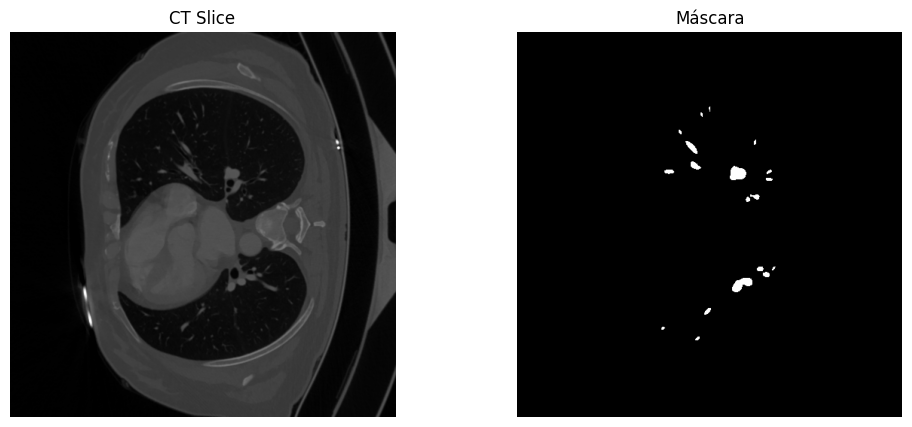

In [33]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CARREGAR VOLUME CT
# =========================

ct_path = "train\PA000005\image\PA000005.nii.gz"

ct_nifti = nib.load(ct_path)
ct_volume = ct_nifti.get_fdata()

print("Formato do volume:", ct_volume.shape)
print("Tipo:", ct_volume.dtype)

# =========================
# CARREGAR MÁSCARA
# =========================

mask_path = "train\PA000005\label\PA000005.nii.gz"

mask_nifti = nib.load(mask_path)
mask_volume = mask_nifti.get_fdata()

print("Formato da máscara:", mask_volume.shape)

# =========================
# VISUALIZAR SLICE
# =========================

slice_idx = ct_volume.shape[2] // 2

plt.figure(figsize=(12,5))

# CT
plt.subplot(1,2,1)
plt.imshow(ct_volume[:, :, slice_idx], cmap='gray')
plt.title("CT Slice")
plt.axis('off')

# Máscara
plt.subplot(1,2,2)
plt.imshow(mask_volume[:, :, slice_idx], cmap='gray')
plt.title("Máscara")
plt.axis('off')

plt.show()

In [342]:
print(ct_nifti.header.get_zooms())

(np.float32(0.6464844), np.float32(0.6464844), np.float32(1.0))


In [329]:
# Quantos voxels tem a máscara total?
print(f"Total voxels artéria: {mask_volume.sum()}")
print(f"% do volume total: {mask_volume.sum() / mask_volume.size * 100:.2f}%")

# Em quais slices a artéria aparece?
slices_com_arteria = [z for z in range(mask_volume.shape[2]) 
                      if mask_volume[:, :, z].sum() > 0]
print(f"Artéria aparece do slice {min(slices_com_arteria)} ao {max(slices_com_arteria)}")
print(f"Total de slices com artéria: {len(slices_com_arteria)}")

Total voxels artéria: 293043.0
% do volume total: 0.43%
Artéria aparece do slice 6 ao 226
Total de slices com artéria: 221


In [34]:
print("Valor mínimo:", np.min(ct_volume))
print("Valor máximo:", np.max(ct_volume))
print("Média:", np.mean(ct_volume))

Valor mínimo: -1024.0
Valor máximo: 3071.0
Média: -480.9754045028095


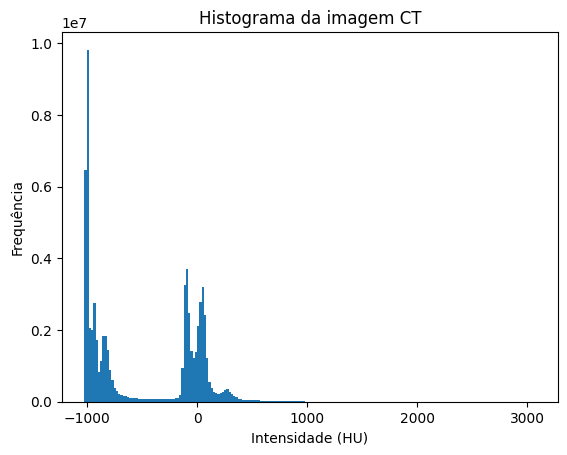

In [168]:
import matplotlib.pyplot as plt
import numpy as np

plt.hist(ct_volume.flatten(), bins=200)
plt.title("Histograma da imagem CT")
plt.xlabel("Intensidade (HU)")
plt.ylabel("Frequência")
plt.show()

In [330]:
ct_clipped = np.clip(ct_volume, -100, 400)

print("Novo mínimo:", ct_clipped.min())
print("Novo máximo:", ct_clipped.max())

Novo mínimo: -100.0
Novo máximo: 400.0


In [331]:
ct_normalized = (ct_clipped - ct_clipped.min()) / (
    ct_clipped.max() - ct_clipped.min()
)

print("Min normalizado:", ct_normalized.min())
print("Max normalizado:", ct_normalized.max())

Min normalizado: 0.0
Max normalizado: 1.0


In [332]:
'''from scipy.ndimage import gaussian_filter

# sigma em voxels, compensando a anisotropia
sigma_mm = 0.8  # mm
voxel_size = [0.7, 0.7, 1.0]  # exemplo, leia do header .nii.gz

sigma_voxels = [sigma_mm / v for v in voxel_size]
# → [1.14, 1.14, 0.8] voxels

ct_smooth = gaussian_filter(ct_clipped, sigma=sigma_voxels)'''

'from scipy.ndimage import gaussian_filter\n\n# sigma em voxels, compensando a anisotropia\nsigma_mm = 0.8  # mm\nvoxel_size = [0.7, 0.7, 1.0]  # exemplo, leia do header .nii.gz\n\nsigma_voxels = [sigma_mm / v for v in voxel_size]\n# → [1.14, 1.14, 0.8] voxels\n\nct_smooth = gaussian_filter(ct_clipped, sigma=sigma_voxels)'

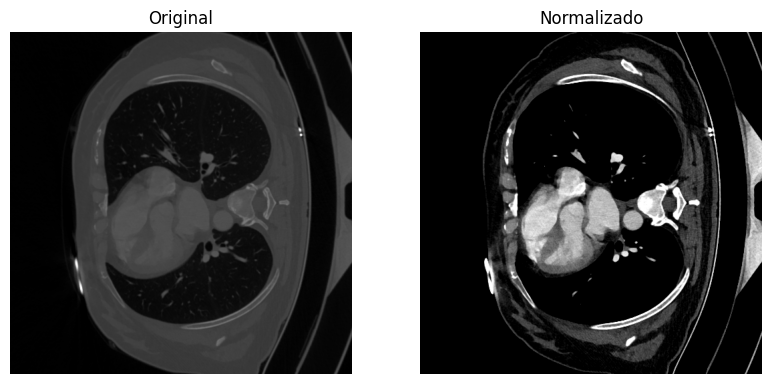

In [333]:
slice_idx = ct_volume.shape[2] // 2

plt.figure(figsize=(15,5))

# ORIGINAL
plt.subplot(1,3,1)
plt.imshow(ct_volume[:, :, slice_idx], cmap='gray')
plt.title("Original")
plt.axis('off')

# NORMALIZADO
plt.subplot(1,3,2)
plt.imshow(ct_normalized[:, :, slice_idx], cmap='gray')
plt.title("Normalizado")
plt.axis('off')

plt.show()

# PARTE 2 - Mascara pulmonar

In [402]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

ct_path = "train/PA000005/image/PA000005.nii.gz"
ct_nifti = nib.load(ct_path)
ct_volume = ct_nifti.get_fdata()

mask_path = "train/PA000005/label/PA000005.nii.gz"
mask_nifti = nib.load(mask_path)
mask_volume = mask_nifti.get_fdata()

# Clip que cobre ar do pulmão (-1000) até contraste arterial (+600)
img_clip = np.clip(ct_volume, -1000, 600)
img_norm = (img_clip - (-1000)) / (600 - (-1000))  # 0–1

# Agora no espaço normalizado:
# Ar do pulmão (~-800 HU) → ~0.125
# Tecido mole (~50 HU)    → ~0.656
# Artéria com contraste (~400 HU) → ~0.875
# Osso (~700 HU, clipado) → 1.0

print("Volume shape:", ct_volume.shape)
print("Voxel spacing:", ct_nifti.header.get_zooms())
print("img_norm min:", img_norm.min(), "max:", img_norm.max())

# Verifica onde estão as artérias no espaço normalizado
arterias = mask_volume > 0
print(f"\nHU das artérias — min: {ct_volume[arterias].min():.0f}, "
      f"max: {ct_volume[arterias].max():.0f}, "
      f"média: {ct_volume[arterias].mean():.0f}")
print(f"Norm das artérias — min: {img_norm[arterias].min():.3f}, "
      f"max: {img_norm[arterias].max():.3f}, "
      f"média: {img_norm[arterias].mean():.3f}")

Volume shape: (512, 512, 258)
Voxel spacing: (np.float32(0.6464844), np.float32(0.6464844), np.float32(1.0))
img_norm min: 0.0 max: 1.0

HU das artérias — min: -944, max: 1206, média: 51
Norm das artérias — min: 0.035, max: 1.000, média: 0.657


Máscara do pulmão: 8080389 voxels ativos


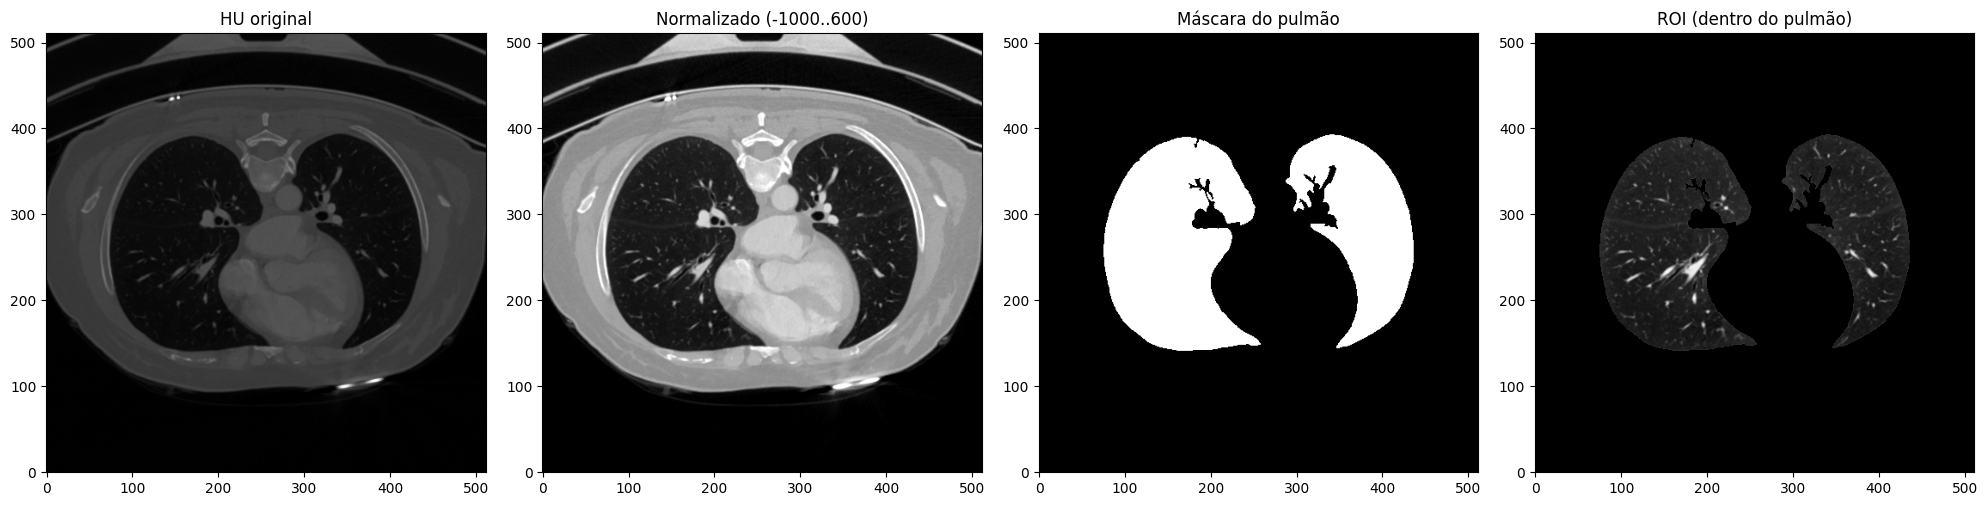

Voxels de artéria total:        293043
Voxels de artéria dentro da ROI: 101767 (34.7%)


In [435]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Carrega dados ──────────────────────────────────────────────────────────
ct_path = "train/PA000005/image/PA000005.nii.gz"
mask_path = "train/PA000005/label/PA000005.nii.gz"

ct_nifti = nib.load(ct_path)
ct_volume = ct_nifti.get_fdata()

mask_nifti = nib.load(mask_path)
mask_volume = mask_nifti.get_fdata()

# ── 2. Clip e normalização ────────────────────────────────────────────────────
# Cobre ar do pulmão (-1000) até contraste arterial (+600)
# Artéria média ~51 HU → normalizado ~0.657
img_clip = np.clip(ct_volume, -1000, 600)
img_norm = (img_clip - (-1000)) / (600 - (-1000))

# ── 3. Máscara do pulmão ──────────────────────────────────────────────────────
# Agora com clip correto, ar do pulmão fica em ~0.0 a ~0.15
from scipy.ndimage import binary_fill_holes, label, binary_dilation, binary_erosion
from skimage.morphology import remove_small_objects

def criar_mascara_pulmao(img_norm, z):
    fatia = img_norm[:, :, z].T

    # Isola corpo
    mascara_corpo = binary_fill_holes(fatia > 0.10)
    mascara_corpo = remove_small_objects(mascara_corpo, max_size=5000)
    labeled_corpo, n = label(mascara_corpo)
    if n == 0:
        return np.zeros_like(fatia, dtype=bool)
    tamanhos = [(labeled_corpo == i).sum() for i in range(1, n+1)]
    mascara_corpo = labeled_corpo == (np.argmax(tamanhos) + 1)

    # Ar dentro do corpo = pulmão candidato
    # Com clip -1000..600: ar (~-800 HU) → norm ~0.125
    mascara_ar = (fatia < 0.20) & mascara_corpo
    mascara_ar = remove_small_objects(mascara_ar, max_size=3000)
    if mascara_ar.sum() == 0:
        return np.zeros_like(fatia, dtype=bool)

    # Labela, separa pulmão esq/dir, fill individual
    labeled_ar, n_ar = label(mascara_ar)
    tamanhos_ar = [(labeled_ar == i).sum() for i in range(1, n_ar+1)]
    idx_ord = np.argsort(tamanhos_ar)[::-1]

    mascara_final = np.zeros_like(fatia, dtype=bool)
    for idx in idx_ord[:2]:
        comp = labeled_ar == (idx + 1)
        comp = binary_fill_holes(comp)
        if comp.sum() > 1000:
            mascara_final |= comp

    if mascara_final.sum() < 1000:
        return np.zeros_like(fatia, dtype=bool)

    return mascara_final

# Constrói volume 3D da máscara
H, W, Z = img_norm.shape
mascara_pulmao = np.zeros((H, W, Z), dtype=bool)
for z in range(Z):
    mascara_pulmao[:, :, z] = criar_mascara_pulmao(img_norm, z).T

print(f"Máscara do pulmão: {mascara_pulmao.sum()} voxels ativos")

# ── 4. Visualização do pré-processamento ─────────────────────────────────────
z = img_norm.shape[2] // 2  # slice do meio

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(ct_volume[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title('HU original')

axes[1].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[1].set_title('Normalizado (-1000..600)')

axes[2].imshow(mascara_pulmao[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Máscara do pulmão')

# Imagem com máscara aplicada
img_roi = img_norm.copy()
img_roi[~mascara_pulmao] = 0
axes[3].imshow(img_roi[:, :, z].T, cmap='gray', origin='lower')
axes[3].set_title('ROI (dentro do pulmão)')

plt.tight_layout()
plt.show()

# ── 5. Verifica artérias dentro da máscara ───────────────────────────────────
arterias = mask_volume > 0
dentro = arterias & mascara_pulmao
print(f"Voxels de artéria total:        {arterias.sum()}")
print(f"Voxels de artéria dentro da ROI: {dentro.sum()} "
      f"({100*dentro.sum()/arterias.sum():.1f}%)")

Voxels de artéria total:              293043
Com máscara original:  101767 (34.7%)
Com máscara dilatada:  175961 (60.0%)


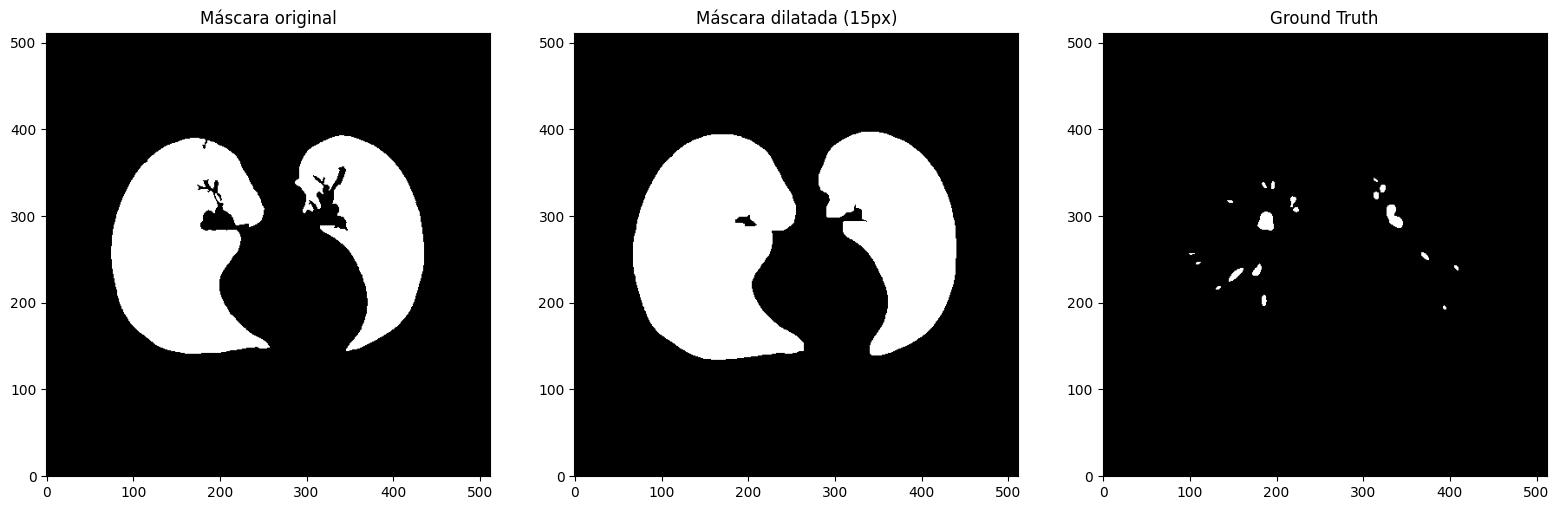

In [428]:
# Após construir mascara_pulmao, dilata para incluir região hilar
from scipy.ndimage import binary_dilation
import numpy as np

# Dilata 15px em todas as direções — cobre hilo e artérias periféricas
struct = np.ones((3, 3, 3), dtype=bool)  # estruturante 3D
mascara_pulmao_dilatada = binary_dilation(mascara_pulmao, structure=struct, iterations=4)

# Verifica cobertura com a máscara dilatada
arterias = mask_volume > 0
dentro_dilatada = arterias & mascara_pulmao_dilatada
print(f"Voxels de artéria total:              {arterias.sum()}")
print(f"Com máscara original:  {(arterias & mascara_pulmao).sum()} ({100*(arterias & mascara_pulmao).sum()/arterias.sum():.1f}%)")
print(f"Com máscara dilatada:  {dentro_dilatada.sum()} ({100*dentro_dilatada.sum()/arterias.sum():.1f}%)")

# Visualiza diferença
z = img_norm.shape[2] // 2
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(mascara_pulmao[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title('Máscara original')
axes[1].imshow(mascara_pulmao_dilatada[:, :, z].T, cmap='gray', origin='lower')
axes[1].set_title('Máscara dilatada (15px)')
axes[2].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth')
plt.tight_layout()
plt.show()

Rodando Frangi... (pode demorar alguns minutos)
  slice 0/258
  slice 20/258
  slice 40/258
  slice 60/258
  slice 80/258
  slice 100/258
  slice 120/258
  slice 140/258
  slice 160/258
  slice 180/258
  slice 200/258
  slice 220/258
  slice 240/258
Frangi concluído!
frangi_volume min: 0.0000, max: 0.0003


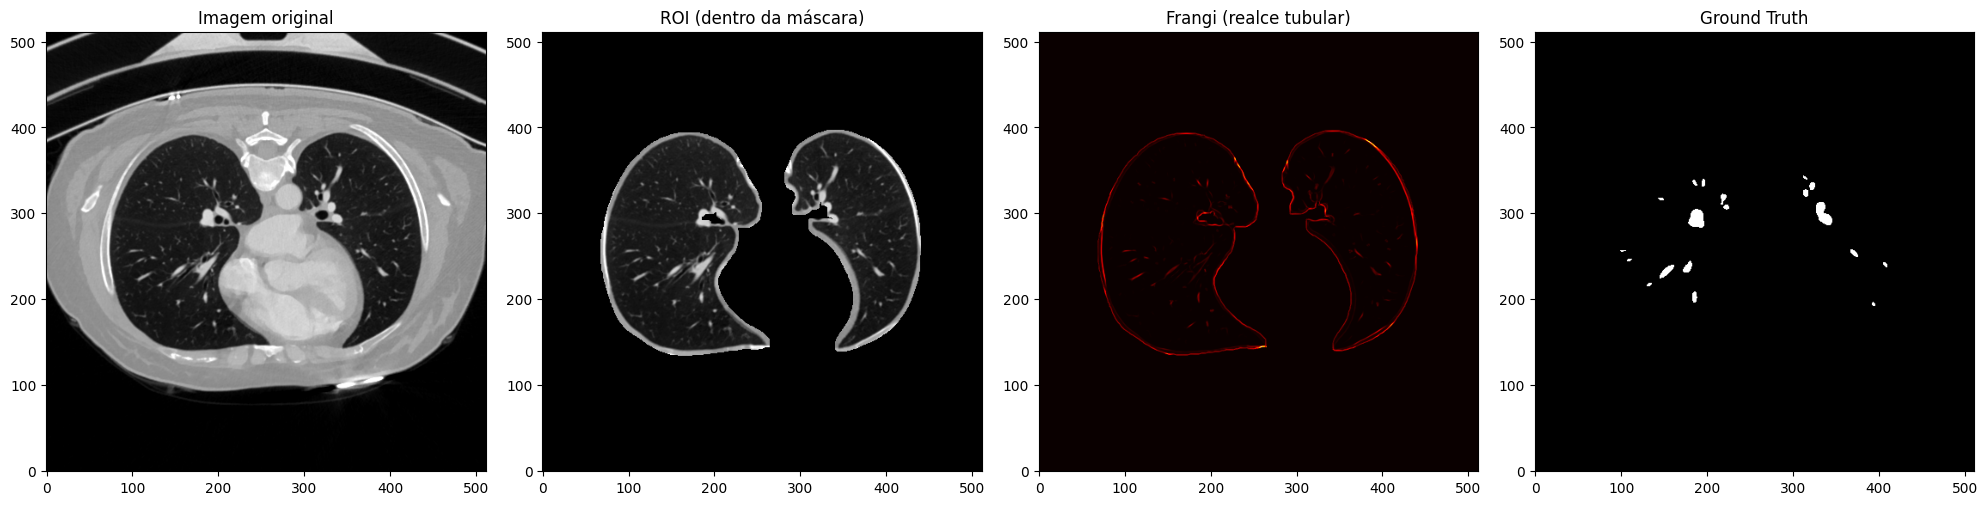

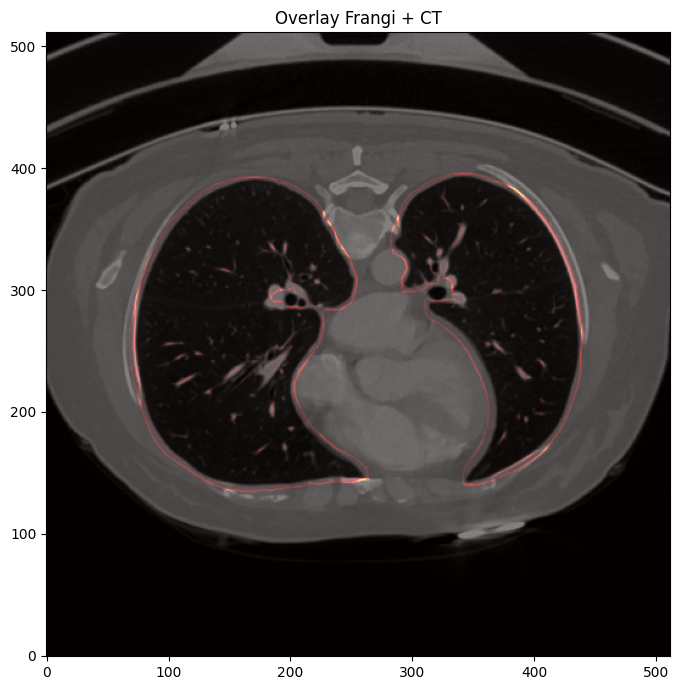

In [430]:
from skimage.filters import frangi
import numpy as np
import matplotlib.pyplot as plt

# ── Aplica máscara na imagem normalizada ──────────────────────────────────────
img_roi = img_norm.copy()
img_roi[~mascara_pulmao_dilatada] = 0

# ── Frangi 3D slice por slice ─────────────────────────────────────────────────
# Frangi 3D completo é muito pesado — aplicar slice por slice é o padrão
# sigmas: escalas dos vasos a detectar (em pixels)
# scale_range e scale_step controlam quais tamanhos de tubo detectar
# beta: sensibilidade a desvio da forma tubular (padrão 0.5)
# gamma: sensibilidade a ruído de fundo (padrão 15)

print("Rodando Frangi... (pode demorar alguns minutos)")

frangi_volume = np.zeros_like(img_roi)
Z = img_roi.shape[2]

for z in range(Z):
    if z % 20 == 0:
        print(f"  slice {z}/{Z}")
    fatia = img_roi[:, :, z].T  # (H, W)
    if fatia.max() == 0:        # slice vazio (fora da ROI)
        continue
    frangi_volume[:, :, z] = frangi(
        fatia,
        sigmas=range(1, 6),   # detecta vasos de 1 a 5px de raio
        alpha=0.5,             # sensibilidade a estrutura de placa vs tubo
        beta=0.5,              # sensibilidade a forma tubular
        gamma=15,              # supressão de fundo
        black_ridges=False     # artérias são brilhantes (ridges claros)
    ).T

print("Frangi concluído!")
print(f"frangi_volume min: {frangi_volume.min():.4f}, max: {frangi_volume.max():.4f}")

# ── Visualiza resultado do Frangi ─────────────────────────────────────────────
z = img_norm.shape[2] // 2

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title('Imagem original')

axes[1].imshow(img_roi[:, :, z].T, cmap='gray', origin='lower')
axes[1].set_title('ROI (dentro da máscara)')

axes[2].imshow(frangi_volume[:, :, z].T, cmap='hot', origin='lower')
axes[2].set_title('Frangi (realce tubular)')

axes[3].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[3].set_title('Ground Truth')

plt.tight_layout()
plt.show()

# ── Overlay: Frangi sobre imagem original ─────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
ax.imshow(frangi_volume[:, :, z].T, cmap='hot', alpha=0.5, origin='lower')
ax.set_title('Overlay Frangi + CT')
plt.tight_layout()
plt.show()

Reduzindo volume de 512x512x258 para 128x128x258...
Rodando Frangi 3D...
min: 0.000000, max: 0.005242


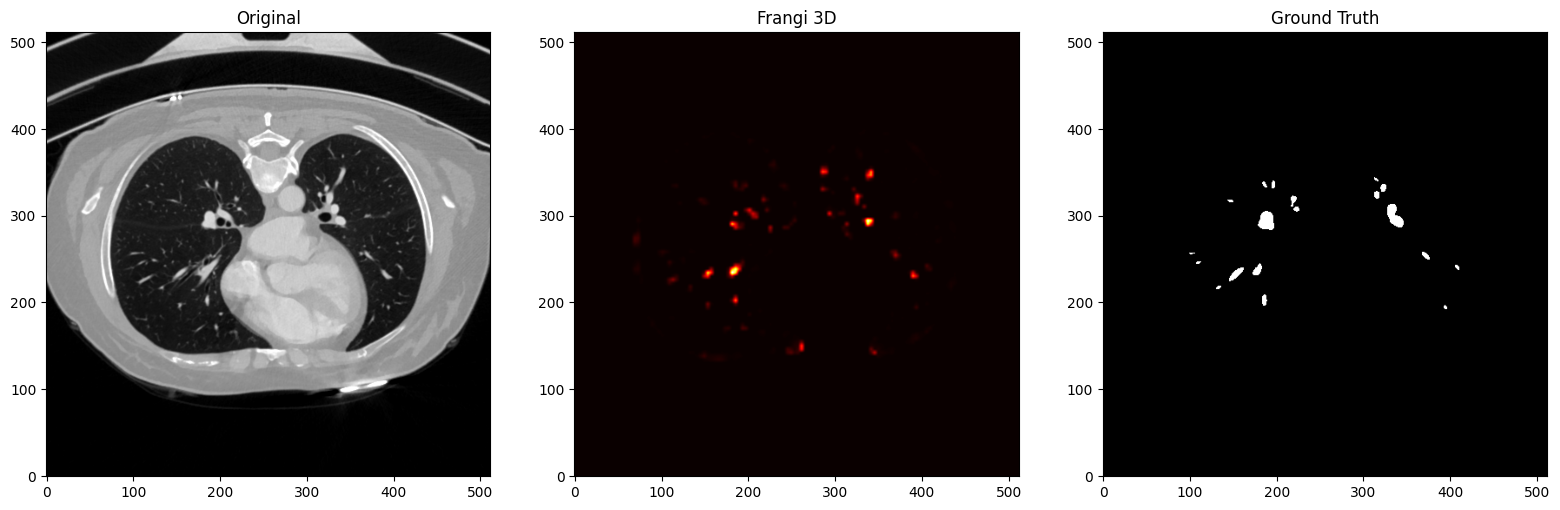

In [431]:
from skimage.filters import frangi
from skimage.transform import resize
import numpy as np

# Reduz o volume pra rodar Frangi 3D (512→128 em X e Y)
fator = 0.25
H, W, Z = img_roi.shape
Hr, Wr = int(H*fator), int(W*fator)

print(f"Reduzindo volume de {H}x{W}x{Z} para {Hr}x{Wr}x{Z}...")
img_pequena = resize(img_roi, (Hr, Wr, Z), anti_aliasing=True)

print("Rodando Frangi 3D...")
frangi_3d = frangi(
    img_pequena,
    sigmas=range(1, 4),
    alpha=0.5,
    beta=0.5,
    gamma=2,
    black_ridges=False
)

# Volta pro tamanho original
frangi_volume = resize(frangi_3d, (H, W, Z), anti_aliasing=True)
print(f"min: {frangi_volume.min():.6f}, max: {frangi_volume.max():.6f}")

# Visualiza
z = img_norm.shape[2] // 2
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title('Original')
axes[1].imshow(frangi_volume[:, :, z].T, cmap='hot', origin='lower')
axes[1].set_title('Frangi 3D')
axes[2].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth')
plt.tight_layout()
plt.show()

Reduzindo volume de 512x512x258 para 256x256x258...
Rodando Frangi 3D... (vai demorar mais ~5-10min)
min: 0.000000, max: 0.008540


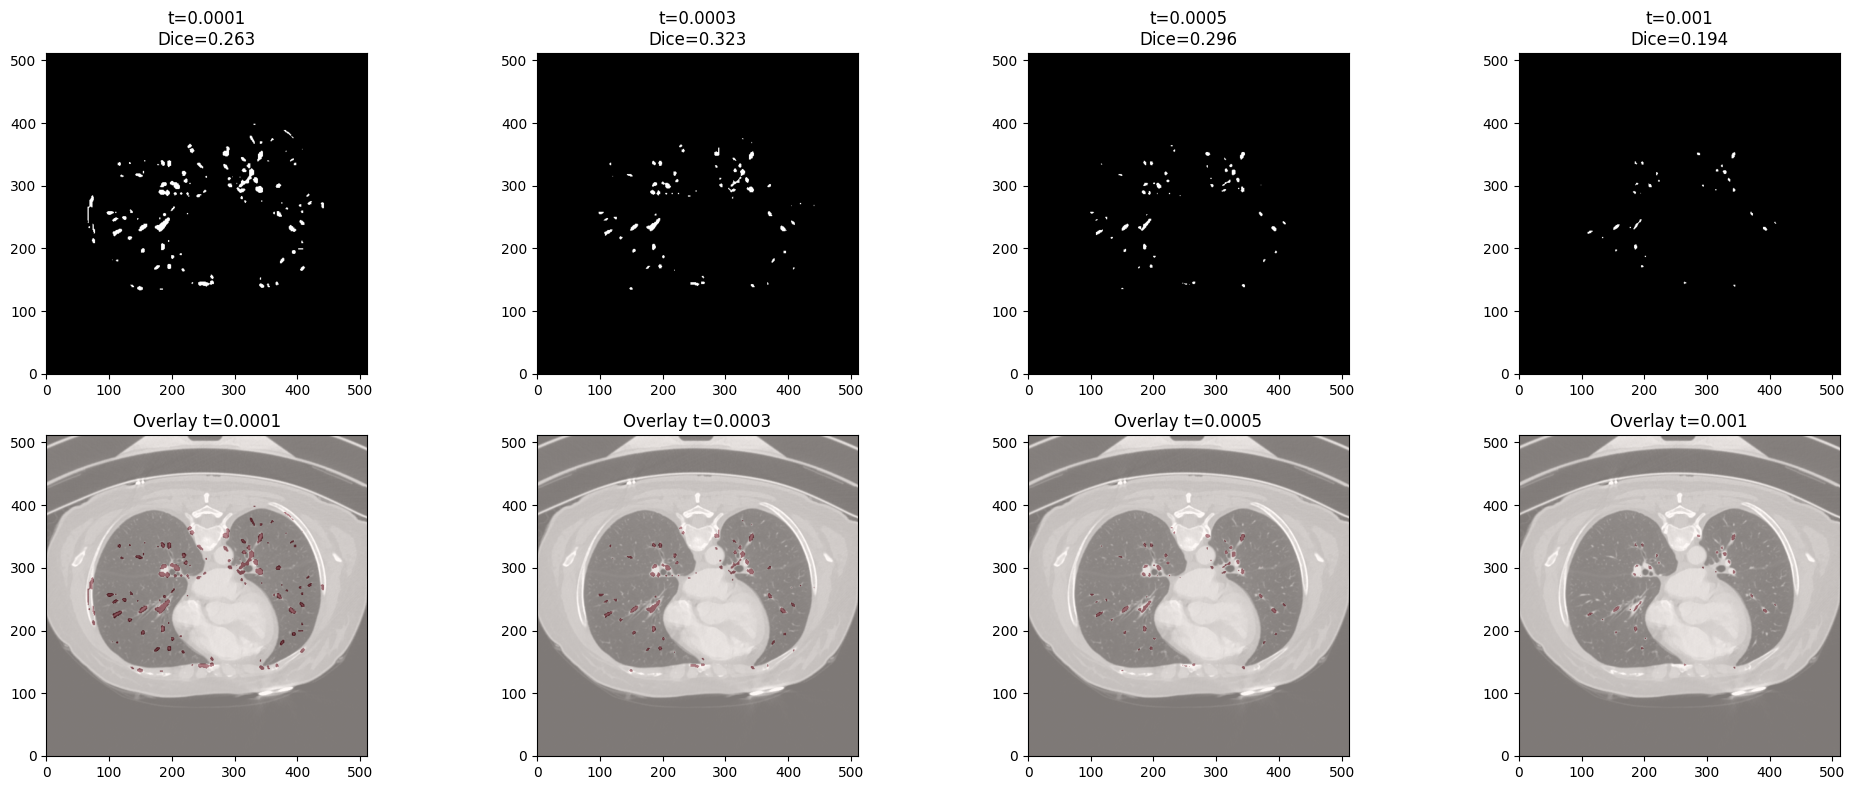

In [421]:
fator = 0.5  # era 0.25, agora 0.5 → 256x256
H, W, Z = img_roi.shape
Hr, Wr = int(H*fator), int(W*fator)

print(f"Reduzindo volume de {H}x{W}x{Z} para {Hr}x{Wr}x{Z}...")
img_pequena = resize(img_roi, (Hr, Wr, Z), anti_aliasing=True)

print("Rodando Frangi 3D... (vai demorar mais ~5-10min)")
frangi_3d = frangi(
    img_pequena,
    sigmas=range(1, 5),
    alpha=0.5,
    beta=0.5,
    gamma=2,
    black_ridges=False
)

frangi_volume = resize(frangi_3d, (H, W, Z), anti_aliasing=True)
print(f"min: {frangi_volume.min():.6f}, max: {frangi_volume.max():.6f}")

# Melhor threshold até agora foi 0.0005 — testa em torno dele
z = img_norm.shape[2] // 2
thresholds = [0.0001, 0.0003, 0.0005, 0.001]

fig, axes = plt.subplots(2, len(thresholds), figsize=(20, 8))
for i, t in enumerate(thresholds):
    seg = frangi_volume > t
    tp = (seg & (mask_volume > 0)).sum()
    fp = (seg & (mask_volume == 0)).sum()
    fn = (~seg & (mask_volume > 0)).sum()
    dice = 2*tp / (2*tp + fp + fn + 1e-6)

    axes[0][i].imshow(seg[:, :, z].T, cmap='gray', origin='lower')
    axes[0][i].set_title(f't={t}\nDice={dice:.3f}')
    axes[1][i].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
    axes[1][i].imshow(seg[:, :, z].T, cmap='Reds', alpha=0.5, origin='lower')
    axes[1][i].set_title(f'Overlay t={t}')

plt.tight_layout()
plt.show()

Voxels após crescimento: 2199289
Dice após crescimento: 0.077


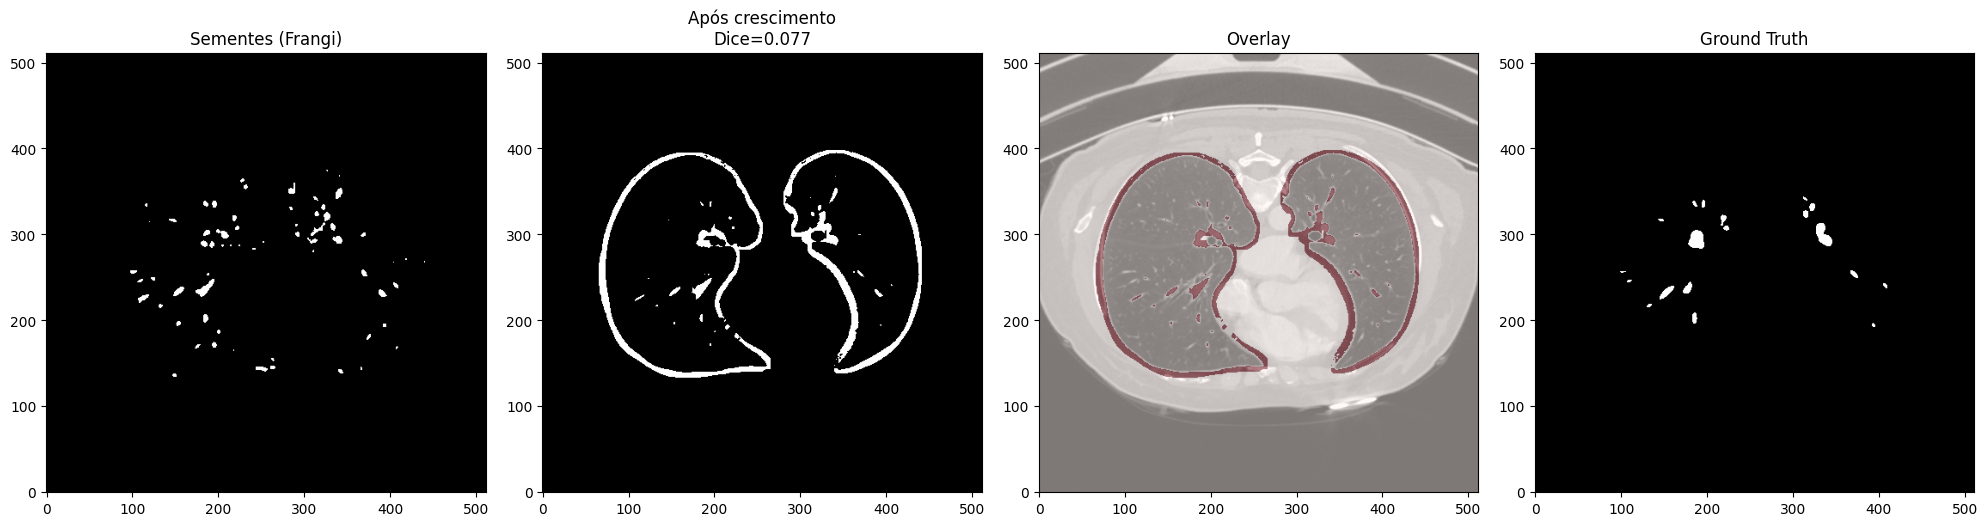

In [422]:
from scipy.ndimage import label
import numpy as np

# ── Sementes = pontos detectados pelo Frangi (threshold 0.0003) ───────────────
sementes = frangi_volume > 0.0003

# ── Crescimento de região 3D ──────────────────────────────────────────────────
# Critério: voxel vizinho entra se o HU normalizado estiver na faixa das artérias
# Artérias têm img_norm entre ~0.5 e ~1.0 (tecido mole com contraste)
limiar_baixo = 0.55
limiar_alto  = 1.00

# Máscara de candidatos: pixels que PODEM ser artéria por intensidade
candidatos = (img_norm >= limiar_baixo) & (img_norm <= limiar_alto) & mascara_pulmao_dilatada

# Crescimento: sementes + todos os candidatos conectados às sementes
from scipy.ndimage import binary_dilation

regiao_crescida = sementes.copy()
for i in range(50):  # máximo 50 iterações
    expandida = binary_dilation(regiao_crescida, iterations=1)
    nova = expandida & candidatos
    if (nova == regiao_crescida).all():
        print(f"Convergiu em {i} iterações")
        break
    regiao_crescida = nova

print(f"Voxels após crescimento: {regiao_crescida.sum()}")

# Avalia
tp = (regiao_crescida & (mask_volume > 0)).sum()
fp = (regiao_crescida & (mask_volume == 0)).sum()
fn = (~regiao_crescida & (mask_volume > 0)).sum()
dice = 2*tp / (2*tp + fp + fn + 1e-6)
print(f"Dice após crescimento: {dice:.3f}")

# Visualiza
z = img_norm.shape[2] // 2
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(sementes[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title('Sementes (Frangi)')
axes[1].imshow(regiao_crescida[:, :, z].T, cmap='gray', origin='lower')
axes[1].set_title(f'Após crescimento\nDice={dice:.3f}')
axes[2].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[2].imshow(regiao_crescida[:, :, z].T, cmap='Reds', alpha=0.5, origin='lower')
axes[2].set_title('Overlay')
axes[3].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[3].set_title('Ground Truth')
plt.tight_layout()
plt.show()

Rodando crescimento de região...
  500000 voxels processados, fila: 4637
Dice: 0.138, voxels: 818783


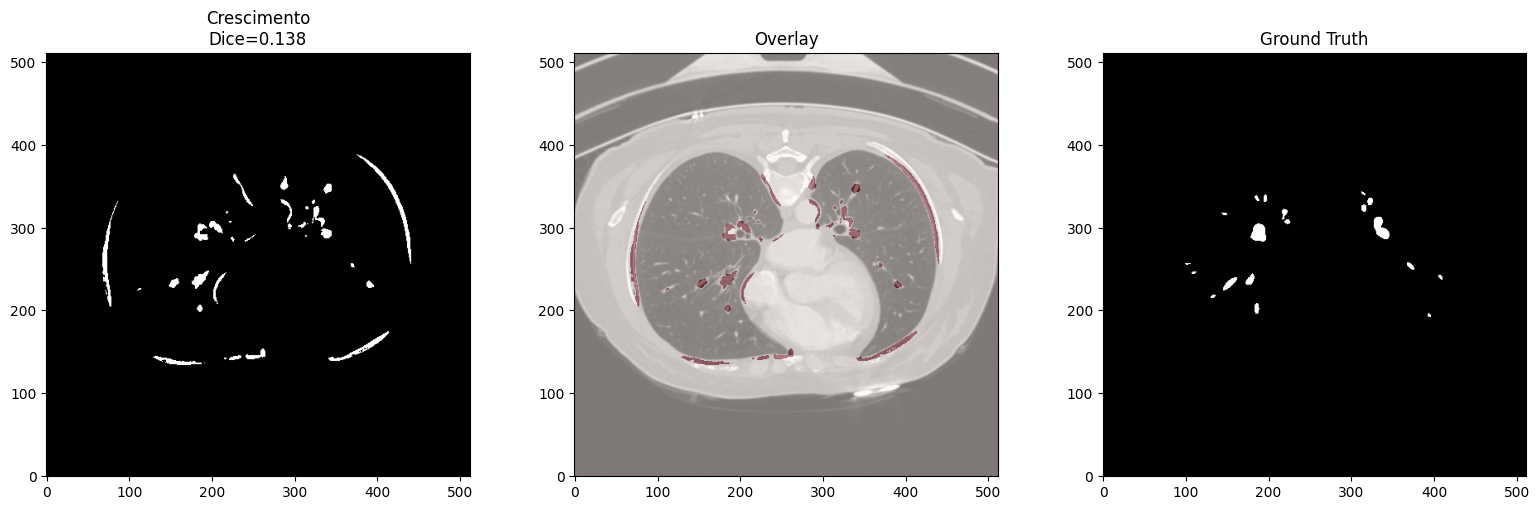

In [432]:
from collections import deque
import numpy as np

def region_growing_3d(img, sementes, limiar_baixo, limiar_alto, mascara):
    resultado = np.zeros_like(img, dtype=bool)
    visitado = np.zeros_like(img, dtype=bool)
    
    fila = deque()
    
    # Inicializa fila com todas as sementes
    coords_sementes = np.argwhere(sementes)
    for coord in coords_sementes:
        x, y, z = coord
        if not visitado[x, y, z]:
            fila.append((x, y, z))
            visitado[x, y, z] = True
            resultado[x, y, z] = True
    
    # 6-conectividade 3D
    vizinhos = [(-1,0,0),(1,0,0),(0,-1,0),(0,1,0),(0,0,-1),(0,0,1)]
    
    H, W, Z = img.shape
    total = 0
    while fila:
        x, y, z = fila.popleft()
        for dx, dy, dz in vizinhos:
            nx, ny, nz = x+dx, y+dy, z+dz
            if 0<=nx<H and 0<=ny<W and 0<=nz<Z:
                if not visitado[nx, ny, nz] and mascara[nx, ny, nz]:
                    if limiar_baixo <= img[nx, ny, nz] <= limiar_alto:
                        visitado[nx, ny, nz] = True
                        resultado[nx, ny, nz] = True
                        fila.append((nx, ny, nz))
        total += 1
        if total % 500000 == 0:
            print(f"  {total} voxels processados, fila: {len(fila)}")
    
    return resultado

# Artérias com contraste ficam em HU alto — no norm (-1000..600) ~0.75 a 1.0
# Limiar mais restrito para não vazar pro parênquima
print("Rodando crescimento de região...")
regiao_crescida = region_growing_3d(
    img_norm,
    sementes=frangi_volume > 0.0005,
    limiar_baixo=0.65,   # ~150 HU — tecido com contraste
    limiar_alto=1.00,
    mascara=mascara_pulmao_dilatada
)

tp = (regiao_crescida & (mask_volume > 0)).sum()
fp = (regiao_crescida & (mask_volume == 0)).sum()
fn = (~regiao_crescida & (mask_volume > 0)).sum()
dice = 2*tp / (2*tp + fp + fn + 1e-6)
print(f"Dice: {dice:.3f}, voxels: {regiao_crescida.sum()}")

z = img_norm.shape[2] // 2
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(regiao_crescida[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title(f'Crescimento\nDice={dice:.3f}')
axes[1].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[1].imshow(regiao_crescida[:, :, z].T, cmap='Reds', alpha=0.5, origin='lower')
axes[1].set_title('Overlay')
axes[2].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth')
plt.tight_layout()
plt.show()

Rodando crescimento de região...
Dice: 0.114, voxels: 1203673


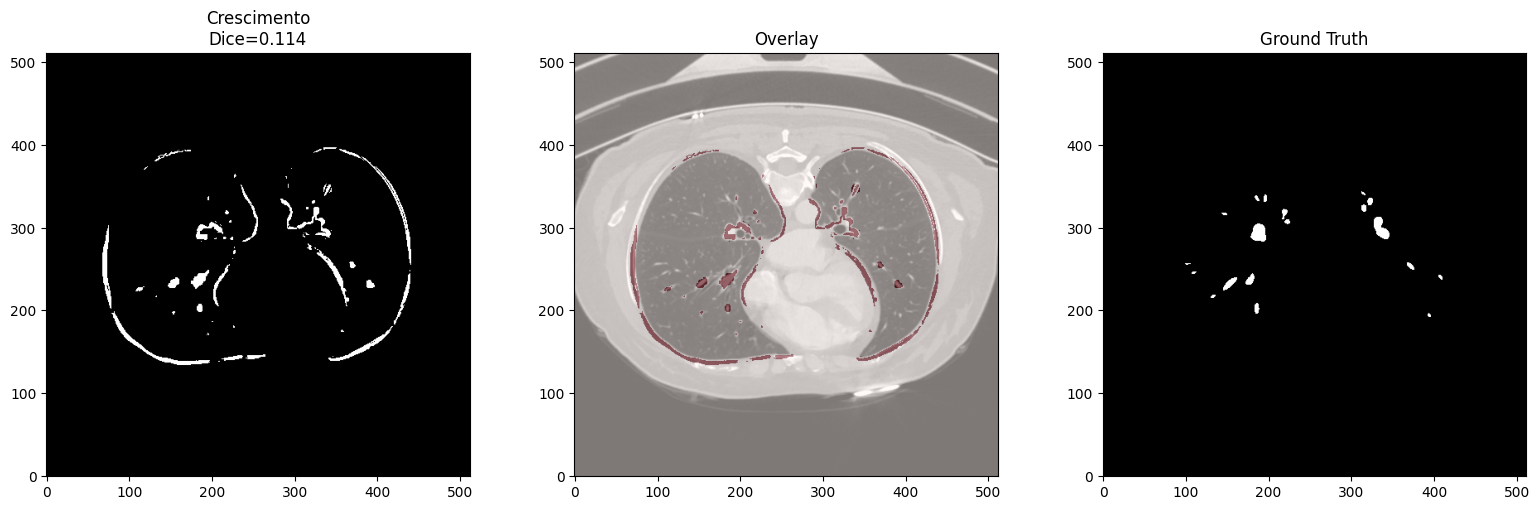

In [434]:
from collections import deque
import numpy as np

def region_growing_3d(img, sementes, limiar_baixo, limiar_alto, mascara, tolerancia=0.05):
    resultado = np.zeros_like(img, dtype=bool)
    visitado = np.zeros_like(img, dtype=bool)
    fila = deque()

    coords_sementes = np.argwhere(sementes)
    for coord in coords_sementes:
        x, y, z = coord
        if not visitado[x, y, z]:
            fila.append((x, y, z, img[x, y, z]))
            visitado[x, y, z] = True
            resultado[x, y, z] = True

    vizinhos = [(-1,0,0),(1,0,0),(0,-1,0),(0,1,0),(0,0,-1),(0,0,1)]
    H, W, Z = img.shape

    while fila:
        x, y, z, val_origem = fila.popleft()
        for dx, dy, dz in vizinhos:
            nx, ny, nz = x+dx, y+dy, z+dz
            if 0 <= nx < H and 0 <= ny < W and 0 <= nz < Z:
                if not visitado[nx, ny, nz] and mascara[nx, ny, nz]:
                    val = img[nx, ny, nz]
                    if limiar_baixo <= val <= limiar_alto and abs(val - val_origem) <= tolerancia:
                        visitado[nx, ny, nz] = True
                        resultado[nx, ny, nz] = True
                        fila.append((nx, ny, nz, val))
    return resultado

print("Rodando crescimento de região...")
regiao_crescida = region_growing_3d(
    img_norm,
    sementes=(frangi_volume > 0.0003) & mascara_pulmao,
    limiar_baixo=0.60,
    limiar_alto=1.00,
    mascara=mascara_pulmao_dilatada,
    tolerancia=0.05
)

tp = (regiao_crescida & (mask_volume > 0)).sum()
fp = (regiao_crescida & (mask_volume == 0)).sum()
fn = (~regiao_crescida & (mask_volume > 0)).sum()
dice = 2*tp / (2*tp + fp + fn + 1e-6)
print(f"Dice: {dice:.3f}, voxels: {regiao_crescida.sum()}")

z = img_norm.shape[2] // 2
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(regiao_crescida[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title(f'Crescimento\nDice={dice:.3f}')
axes[1].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[1].imshow(regiao_crescida[:, :, z].T, cmap='Reds', alpha=0.5, origin='lower')
axes[1].set_title('Overlay')
axes[2].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth')
plt.tight_layout()
plt.show()

Dice:      0.252
Precision: 0.250
Recall:    0.255


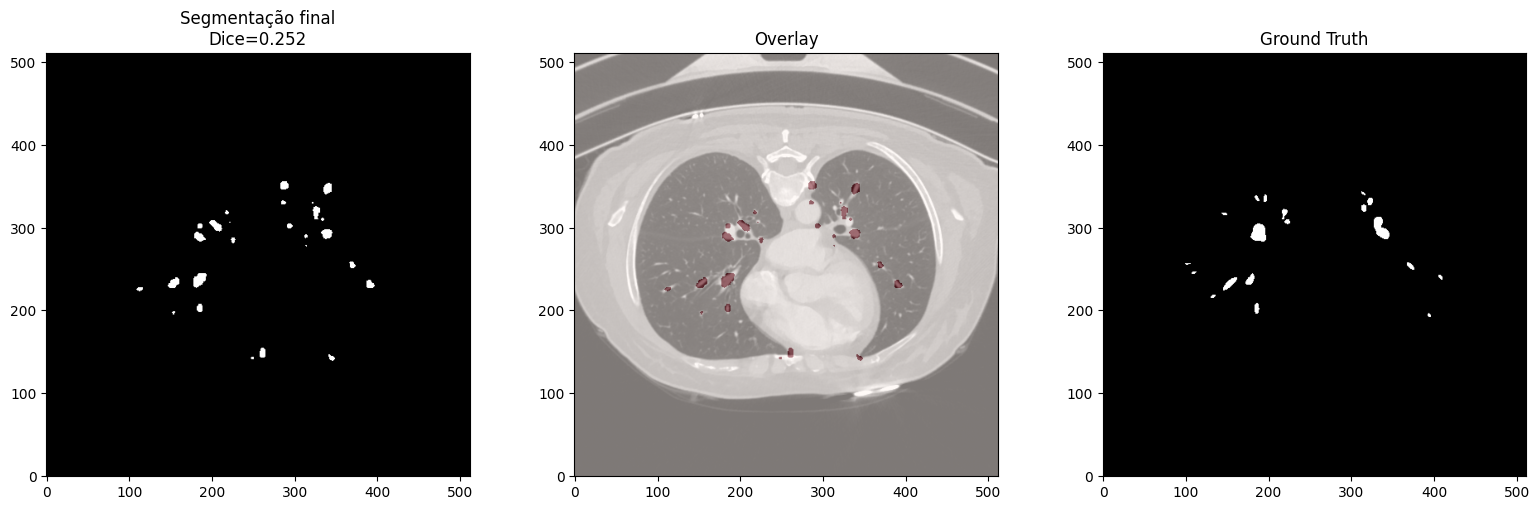

In [437]:
from scipy.ndimage import binary_closing, label
from skimage.morphology import remove_small_objects
import numpy as np

seg = frangi_volume > 0.0003

# 1. Remove só ruído muito pequeno (era 50, agora 10)
seg = remove_small_objects(seg, max_size=10)

# 2. Closing suave para conectar fragmentos
seg = binary_closing(seg, iterations=1)

# Avalia
tp = (seg & (mask_volume > 0)).sum()
fp = (seg & (mask_volume == 0)).sum()
fn = (~seg & (mask_volume > 0)).sum()
dice = 2*tp / (2*tp + fp + fn + 1e-6)
precision = tp / (tp + fp + 1e-6)
recall = tp / (tp + fn + 1e-6)
print(f"Dice:      {dice:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")

z = img_norm.shape[2] // 2
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(seg[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title(f'Segmentação final\nDice={dice:.3f}')
axes[1].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[1].imshow(seg[:, :, z].T, cmap='Reds', alpha=0.5, origin='lower')
axes[1].set_title('Overlay')
axes[2].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth')
plt.tight_layout()
plt.show()

In [438]:
import psutil
ram = psutil.virtual_memory()
print(f"RAM total:     {ram.total / 1e9:.1f} GB")
print(f"RAM disponível: {ram.available / 1e9:.1f} GB")

# Estimativa de memória necessária para Frangi 512x512x258
import numpy as np
shape = (512, 512, 258)
nbytes = np.prod(shape) * 8  # float64
print(f"\nVolume 512x512x258 float64: {nbytes / 1e9:.1f} GB")
print(f"Frangi precisa ~3-5x isso internamente: {3*nbytes/1e9:.1f} - {5*nbytes/1e9:.1f} GB")

RAM total:     16.4 GB
RAM disponível: 1.7 GB

Volume 512x512x258 float64: 0.5 GB
Frangi precisa ~3-5x isso internamente: 1.6 - 2.7 GB


Rodando crescimento de região...
Dice: 0.132, voxels: 1778991


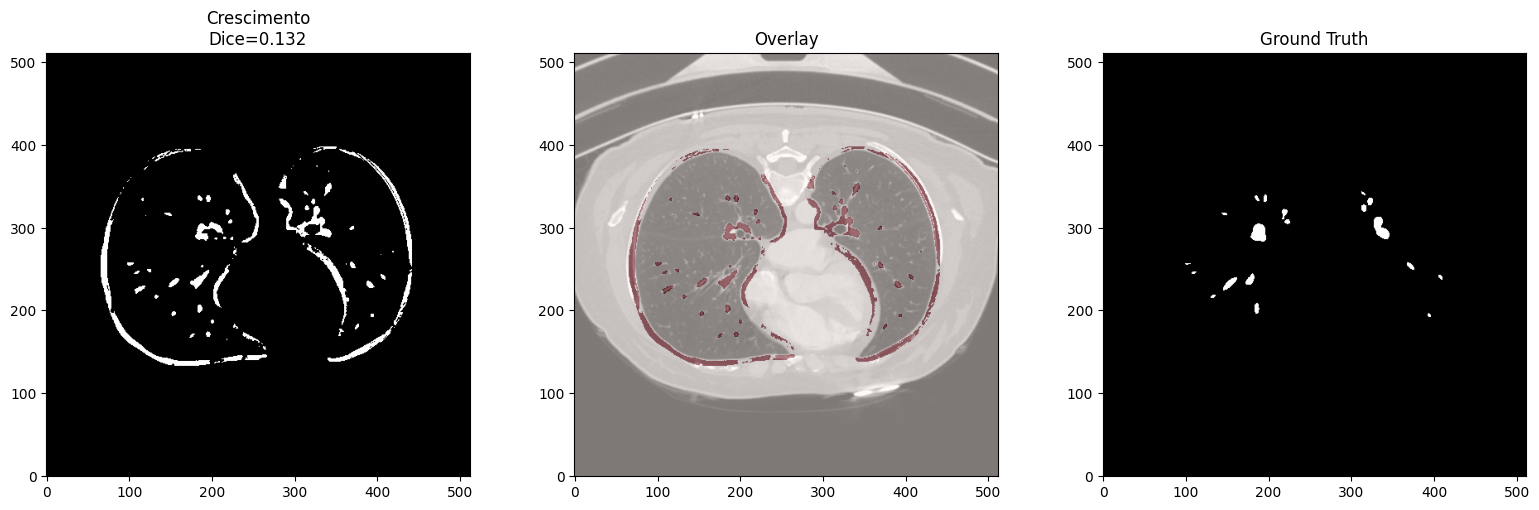

In [427]:
def region_growing_3d(img, sementes, limiar_baixo, limiar_alto, mascara, tolerancia=0.05):
    resultado = np.zeros_like(img, dtype=bool)
    visitado = np.zeros_like(img, dtype=bool)
    fila = deque()

    coords_sementes = np.argwhere(sementes)
    for coord in coords_sementes:
        x, y, z = coord
        if not visitado[x, y, z]:
            fila.append((x, y, z, img[x, y, z]))
            visitado[x, y, z] = True
            resultado[x, y, z] = True

    vizinhos = [(-1,0,0),(1,0,0),(0,-1,0),(0,1,0),(0,0,-1),(0,0,1)]
    H, W, Z = img.shape

    while fila:
        x, y, z, val_origem = fila.popleft()
        for dx, dy, dz in vizinhos:
            nx, ny, nz = x+dx, y+dy, z+dz
            if 0 <= nx < H and 0 <= ny < W and 0 <= nz < Z:
                if not visitado[nx, ny, nz] and mascara[nx, ny, nz]:
                    val = img[nx, ny, nz]
                    if limiar_baixo <= val <= limiar_alto and abs(val - val_origem) <= tolerancia:
                        visitado[nx, ny, nz] = True
                        resultado[nx, ny, nz] = True
                        fila.append((nx, ny, nz, val))

    return resultado  # ← estava faltando isso

print("Rodando crescimento de região...")
regiao_crescida = region_growing_3d(
    img_norm,
    sementes=frangi_volume > 0.0003,
    limiar_baixo=0.60,
    limiar_alto=1.00,
    mascara=mascara_pulmao_dilatada,
    tolerancia=0.05   # máximo 5% de diferença entre vizinhos
)

tp = (regiao_crescida & (mask_volume > 0)).sum()
fp = (regiao_crescida & (mask_volume == 0)).sum()
fn = (~regiao_crescida & (mask_volume > 0)).sum()
dice = 2*tp / (2*tp + fp + fn + 1e-6)
print(f"Dice: {dice:.3f}, voxels: {regiao_crescida.sum()}")

z = img_norm.shape[2] // 2
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(regiao_crescida[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title(f'Crescimento\nDice={dice:.3f}')
axes[1].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[1].imshow(regiao_crescida[:, :, z].T, cmap='Reds', alpha=0.5, origin='lower')
axes[1].set_title('Overlay')
axes[2].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth')
plt.tight_layout()
plt.show()

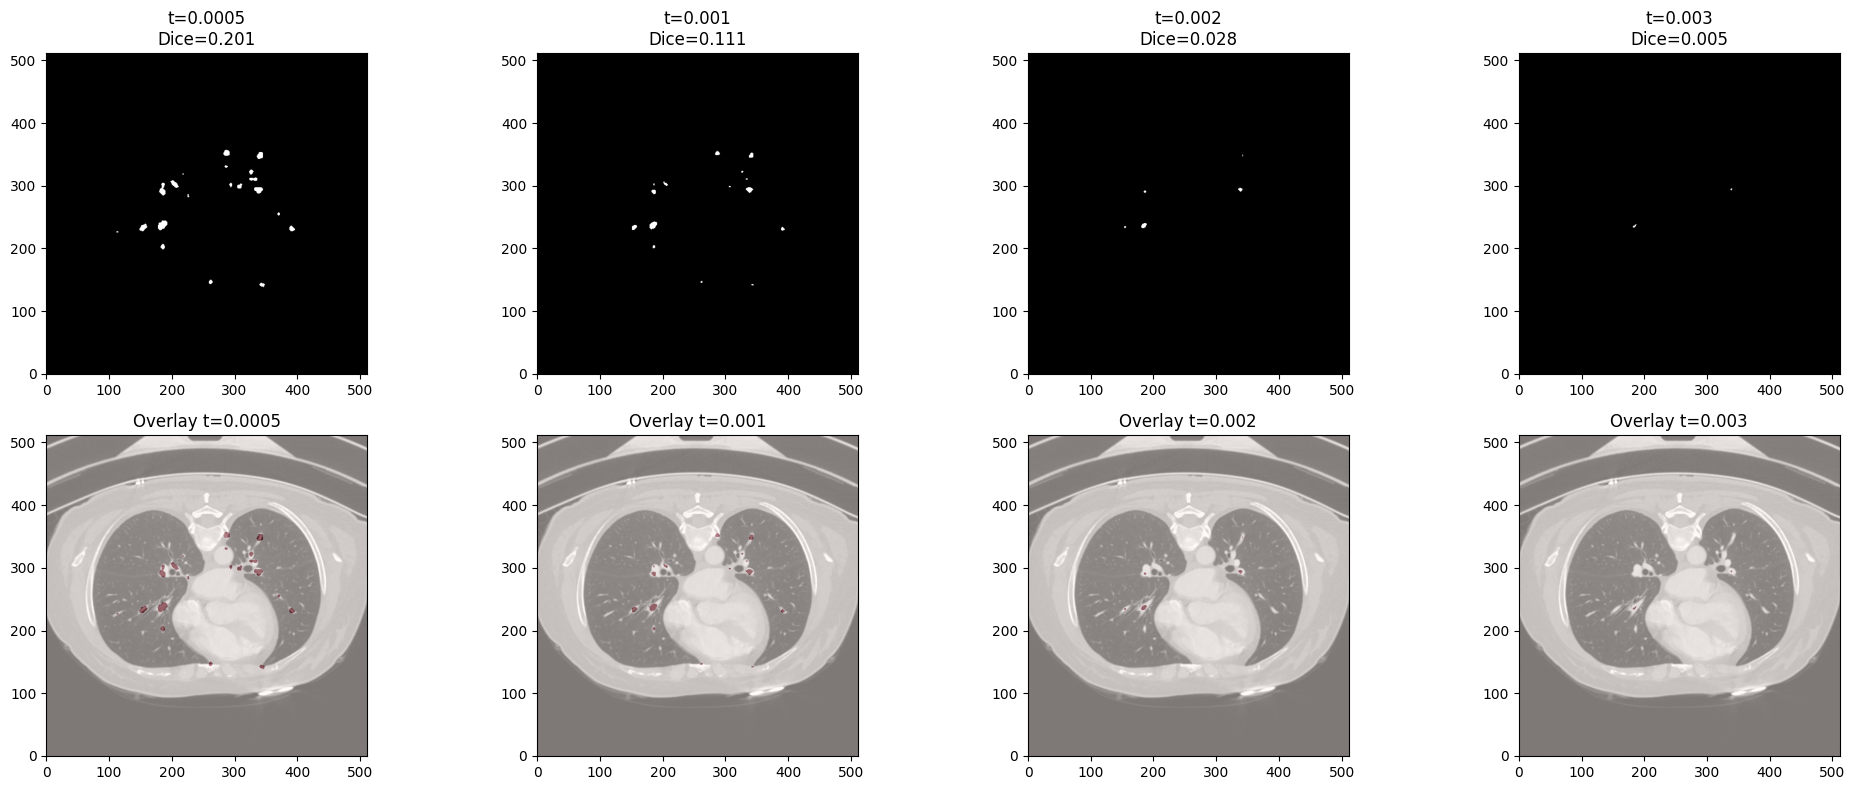

In [420]:
# Testa thresholds no Frangi 3D
z = img_norm.shape[2] // 2
thresholds = [0.0005, 0.001, 0.002, 0.003]

fig, axes = plt.subplots(2, len(thresholds), figsize=(20, 8))
for i, t in enumerate(thresholds):
    seg = frangi_volume > t
    tp = (seg & (mask_volume > 0)).sum()
    fp = (seg & (mask_volume == 0)).sum()
    fn = (~seg & (mask_volume > 0)).sum()
    dice = 2*tp / (2*tp + fp + fn + 1e-6)

    axes[0][i].imshow(seg[:, :, z].T, cmap='gray', origin='lower')
    axes[0][i].set_title(f't={t}\nDice={dice:.3f}')
    axes[1][i].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
    axes[1][i].imshow(seg[:, :, z].T, cmap='Reds', alpha=0.5, origin='lower')
    axes[1][i].set_title(f'Overlay t={t}')

plt.tight_layout()
plt.show()

Rodando Frangi...
  slice 0/258
  slice 20/258
  slice 40/258
  slice 60/258
  slice 80/258
  slice 100/258
  slice 120/258
  slice 140/258
  slice 160/258
  slice 180/258
  slice 200/258
  slice 220/258
  slice 240/258
Frangi concluído! min: 0.000000, max: 0.017336


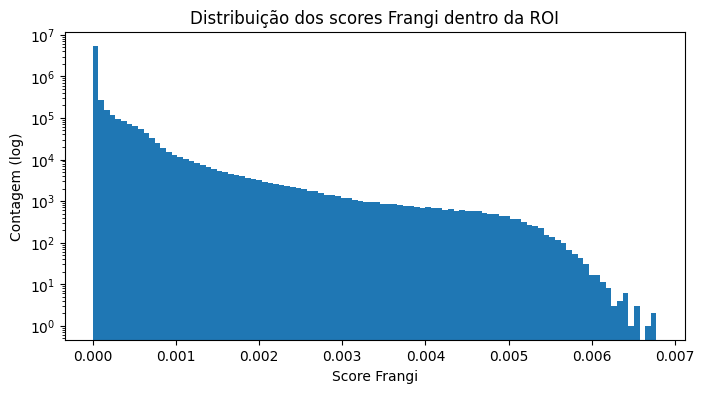

In [411]:
frangi_volume = np.zeros_like(img_roi)
Z = img_roi.shape[2]

print("Rodando Frangi...")
for z in range(Z):
    if z % 20 == 0:
        print(f"  slice {z}/{Z}")
    fatia = img_roi[:, :, z].T
    if fatia.max() == 0:
        continue

    frangi_volume[:, :, z] = frangi(
        fatia,
        sigmas=range(1, 8),   # vasos maiores também
        alpha=0.5,
        beta=0.5,
        gamma=2,               # era 15 — muito restritivo, baixa pra 2
        black_ridges=False
    ).T

print(f"Frangi concluído! min: {frangi_volume.min():.6f}, max: {frangi_volume.max():.6f}")

# Histograma dos valores Frangi (só dentro da ROI)
valores = frangi_volume[mascara_pulmao_dilatada]
plt.figure(figsize=(8, 4))
plt.hist(valores[valores > 0], bins=100, log=True)
plt.xlabel('Score Frangi')
plt.ylabel('Contagem (log)')
plt.title('Distribuição dos scores Frangi dentro da ROI')
plt.show()

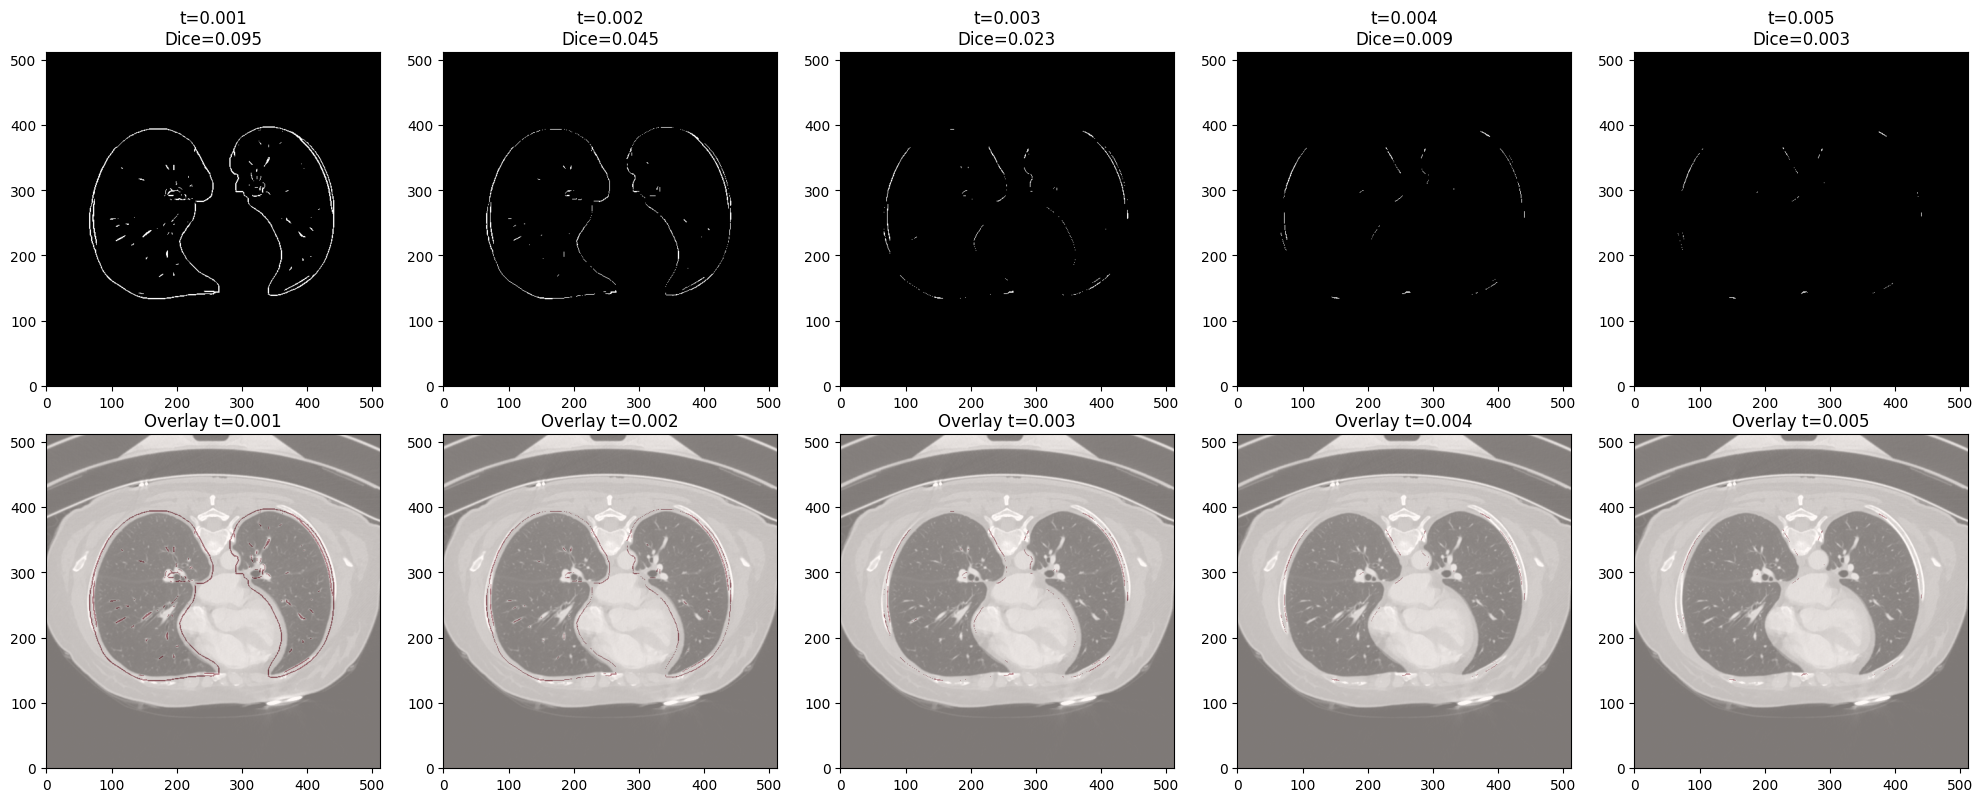

In [412]:
# Testa vários thresholds e compara com ground truth
z = img_norm.shape[2] // 2
thresholds = [0.001, 0.002, 0.003, 0.004, 0.005]

fig, axes = plt.subplots(2, len(thresholds), figsize=(20, 8))

for i, t in enumerate(thresholds):
    seg = frangi_volume > t
    
    # Calcula Dice
    tp = (seg & (mask_volume > 0)).sum()
    fp = (seg & (mask_volume == 0)).sum()
    fn = (~seg & (mask_volume > 0)).sum()
    dice = 2*tp / (2*tp + fp + fn + 1e-6)
    
    axes[0][i].imshow(seg[:, :, z].T, cmap='gray', origin='lower')
    axes[0][i].set_title(f't={t}\nDice={dice:.3f}')
    
    # Overlay sobre CT
    axes[1][i].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
    axes[1][i].imshow(seg[:, :, z].T, cmap='Reds', alpha=0.5, origin='lower')
    axes[1][i].set_title(f'Overlay t={t}')

plt.tight_layout()
plt.show()

C:\Users\reset\AppData\Local\Temp\ipykernel_21028\1424479509.py:10: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_ar_limpa = remove_small_objects(mascara_ar, min_size=10000)


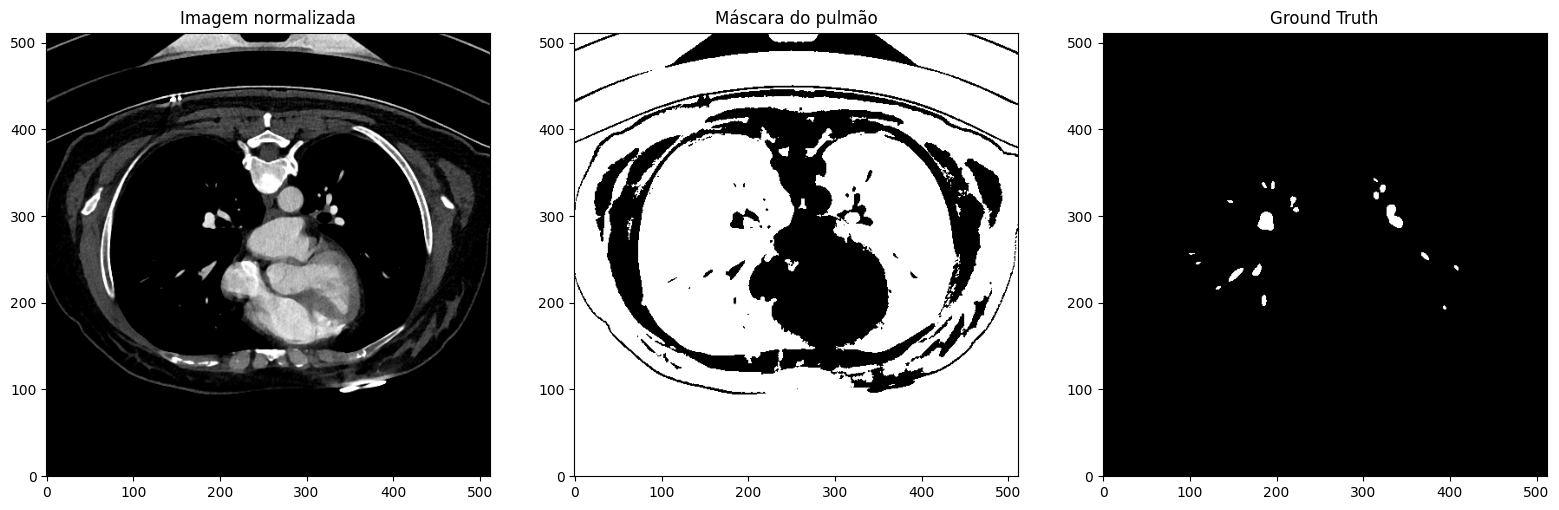

In [ ]:
from scipy.ndimage import binary_fill_holes, label
from skimage.morphology import remove_small_objects

# Pulmão tem HU muito baixo — no espaço normalizado fica próximo de 0
# Com clip -100 a 400: HU -800 → clipado para -100 → normalizado para 0.0
# Threshold baixo captura o ar (pulmão)
mascara_ar = img_norm < 0.15  # pega ar e estruturas escuras

# Remove pequenos componentes (ruído fora do pulmão)
mascara_ar_limpa = remove_small_objects(mascara_ar, min_size=10000)

# Preenche buracos internos (vasos dentro do pulmão aparecem como buracos)
mascara_pulmao = binary_fill_holes(mascara_ar_limpa)

# Remove o fundo (maior componente é o ar externo ao paciente)
# Queremos só os dois pulmões, não o ar fora do corpo
labeled, n = label(mascara_pulmao)
tamanhos = [(labeled == i).sum() for i in range(1, n+1)]
# Pega os 2 maiores componentes (pulmão esquerdo e direito)
idx_ordenados = np.argsort(tamanhos)[::-1]
mascara_pulmao_final = np.zeros_like(mascara_pulmao)
for idx in idx_ordenados[:2]:
    mascara_pulmao_final |= (labeled == idx+1)

# Visualiza
z = 129
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title('Imagem normalizada')
axes[1].imshow(mascara_pulmao_final[:, :, z].T, cmap='gray', origin='lower')
axes[1].set_title('Máscara do pulmão')
axes[2].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth')
plt.tight_layout()
plt.show()

C:\Users\reset\AppData\Local\Temp\ipykernel_21028\1424479509.py:10: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_ar_limpa = remove_small_objects(mascara_ar, min_size=10000)


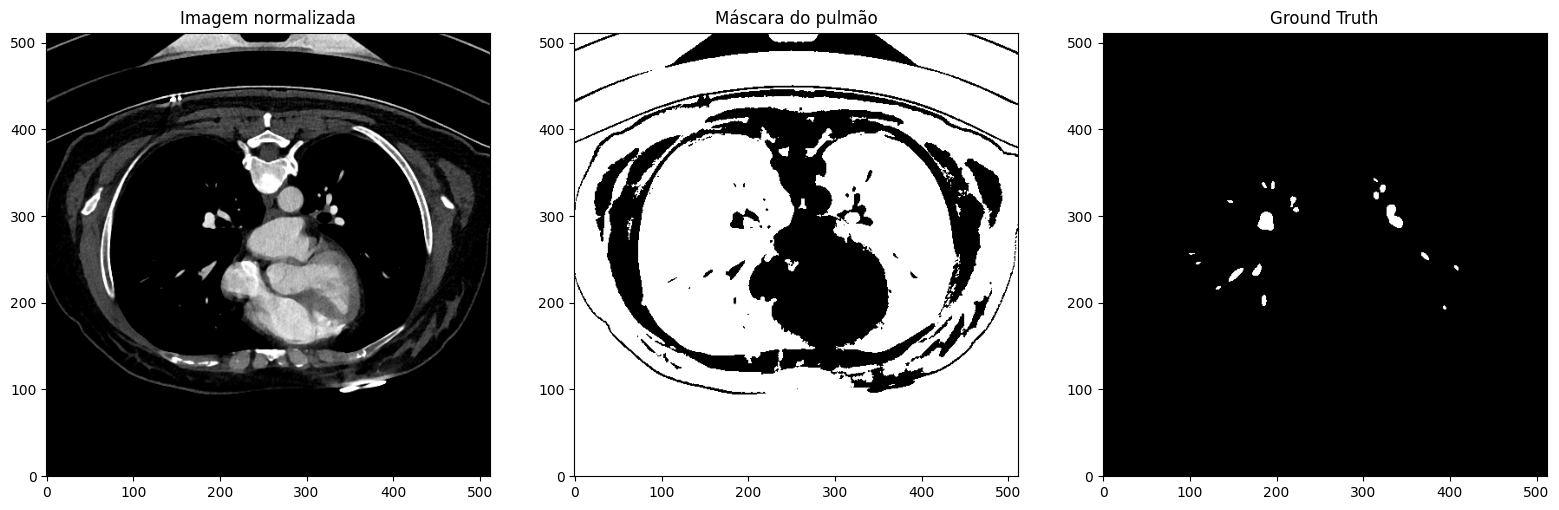

In [397]:
from scipy.ndimage import binary_fill_holes, label
from skimage.morphology import remove_small_objects

# Pulmão tem HU muito baixo — no espaço normalizado fica próximo de 0
# Com clip -100 a 400: HU -800 → clipado para -100 → normalizado para 0.0
# Threshold baixo captura o ar (pulmão)
mascara_ar = img_norm < 0.15  # pega ar e estruturas escuras

# Remove pequenos componentes (ruído fora do pulmão)
mascara_ar_limpa = remove_small_objects(mascara_ar, min_size=10000)

# Preenche buracos internos (vasos dentro do pulmão aparecem como buracos)
mascara_pulmao = binary_fill_holes(mascara_ar_limpa)

# Remove o fundo (maior componente é o ar externo ao paciente)
# Queremos só os dois pulmões, não o ar fora do corpo
labeled, n = label(mascara_pulmao)
tamanhos = [(labeled == i).sum() for i in range(1, n+1)]
# Pega os 2 maiores componentes (pulmão esquerdo e direito)
idx_ordenados = np.argsort(tamanhos)[::-1]
mascara_pulmao_final = np.zeros_like(mascara_pulmao)
for idx in idx_ordenados[:2]:
    mascara_pulmao_final |= (labeled == idx+1)

# Visualiza
z = 129
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title('Imagem normalizada')
axes[1].imshow(mascara_pulmao_final[:, :, z].T, cmap='gray', origin='lower')
axes[1].set_title('Máscara do pulmão')
axes[2].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth')
plt.tight_layout()
plt.show()

C:\Users\reset\AppData\Local\Temp\ipykernel_21028\1937437377.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_limpa = remove_small_objects(mascara_sem_fundo, min_size=3000)


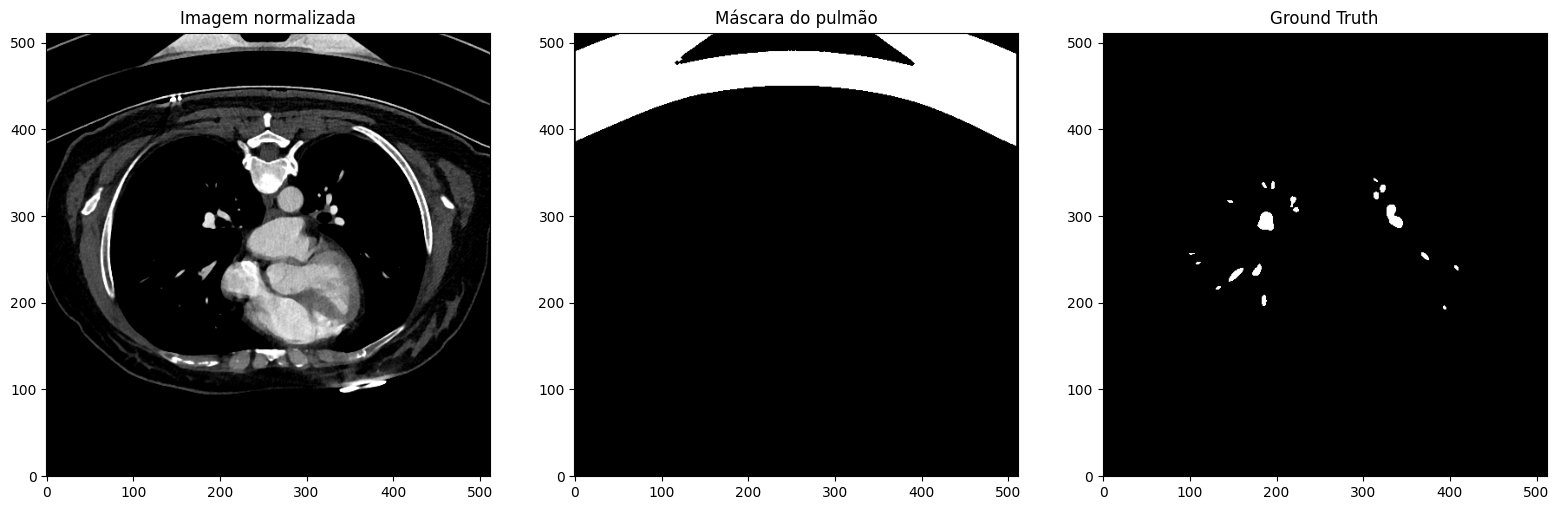

In [394]:
import numpy as np
from scipy.ndimage import binary_fill_holes, label, binary_dilation, binary_erosion
from skimage.morphology import remove_small_objects

def criar_mascara_pulmao(img_norm, z, n_pulmoes=2):
    fatia = img_norm[:, :, z].T  # shape (H, W)

    mascara_ar = fatia < 0.20

    labeled, n = label(mascara_ar)
    if n == 0:
        return np.zeros_like(fatia, dtype=bool)

    tamanhos = [(labeled == i).sum() for i in range(1, n + 1)]

    idx_maior = np.argmax(tamanhos) + 1
    mascara_sem_fundo = mascara_ar.copy()
    mascara_sem_fundo[labeled == idx_maior] = False

    mascara_limpa = remove_small_objects(mascara_sem_fundo, min_size=3000)

    mascara_preenchida = binary_fill_holes(mascara_limpa)

    labeled2, n2 = label(mascara_preenchida)
    if n2 == 0:
        return np.zeros_like(fatia, dtype=bool)

    tamanhos2 = [(labeled2 == i).sum() for i in range(1, n2 + 1)]
    idx_ordenados = np.argsort(tamanhos2)[::-1]

    mascara_final = np.zeros_like(fatia, dtype=bool)
    for idx in idx_ordenados[:n_pulmoes]:
        mascara_final |= (labeled2 == idx + 1)

    mascara_final = binary_dilation(mascara_final, iterations=2)
    mascara_final = binary_erosion(mascara_final, iterations=2)

    # Slice fora da região pulmonar (apical/basal) — zera
    if mascara_final.sum() < 1000:
        mascara_final = np.zeros_like(fatia, dtype=bool)

    return mascara_final


# Aplica slice por slice e reconstrói volume 3D
H, W, Z = img_norm.shape
mascara_pulmao_volume = np.zeros((H, W, Z), dtype=bool)

for z in range(Z):
    mascara_pulmao_volume[:, :, z] = criar_mascara_pulmao(img_norm, z).T

# Visualiza
z = 129
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title('Imagem normalizada')
axes[1].imshow(mascara_pulmao_volume[:, :, z].T, cmap='gray', origin='lower')
axes[1].set_title('Máscara do pulmão')
axes[2].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth')
plt.tight_layout()
plt.show()

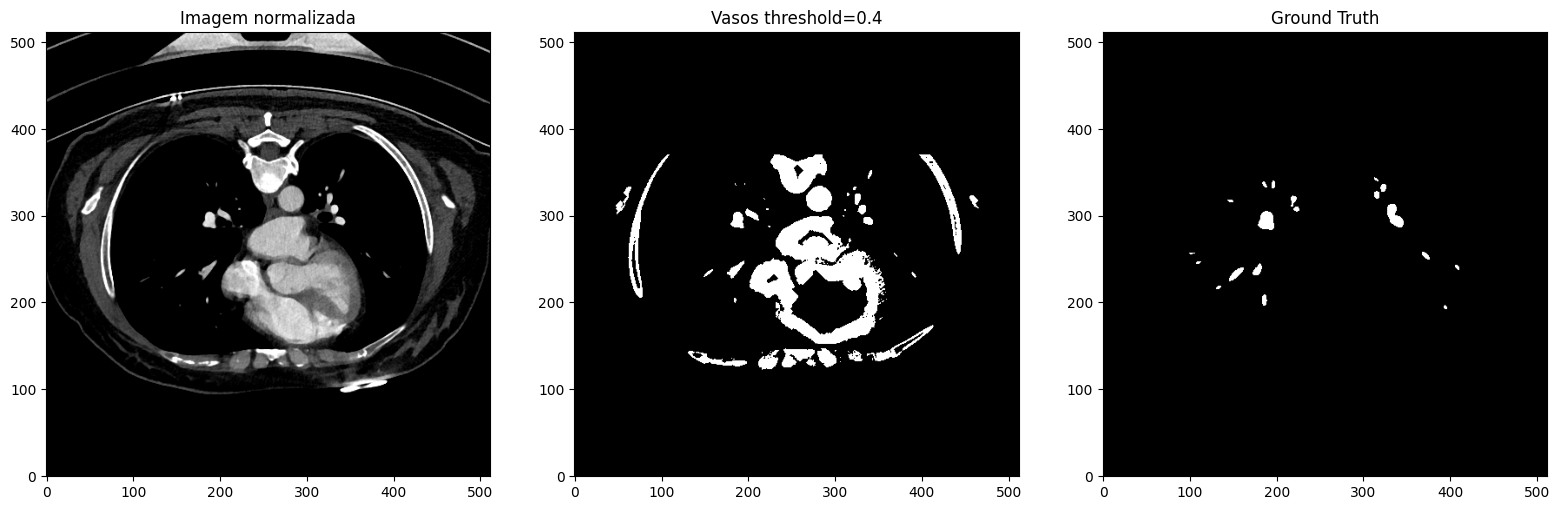

In [365]:
# Aplica ROI
img_roi = img_norm.copy()
img_roi[~mascara_dilatada] = 0

# Corta região superior (costelas/escápulas)
img_roi[:, 370:, :] = 0

# Threshold mais restritivo
threshold = 0.4
mascara_vasos = img_roi > threshold

# Visualiza
z = 129
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title('Imagem normalizada')
axes[1].imshow(mascara_vasos[:, :, z].T, cmap='gray', origin='lower')
axes[1].set_title(f'Vasos threshold={threshold}')
axes[2].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth')
plt.tight_layout()
plt.show()

# PARTE 4 - TESTANDO CRESCIMENTO POR REGIÃO

Componentes sem blur: 23298
Componentes com blur: 515


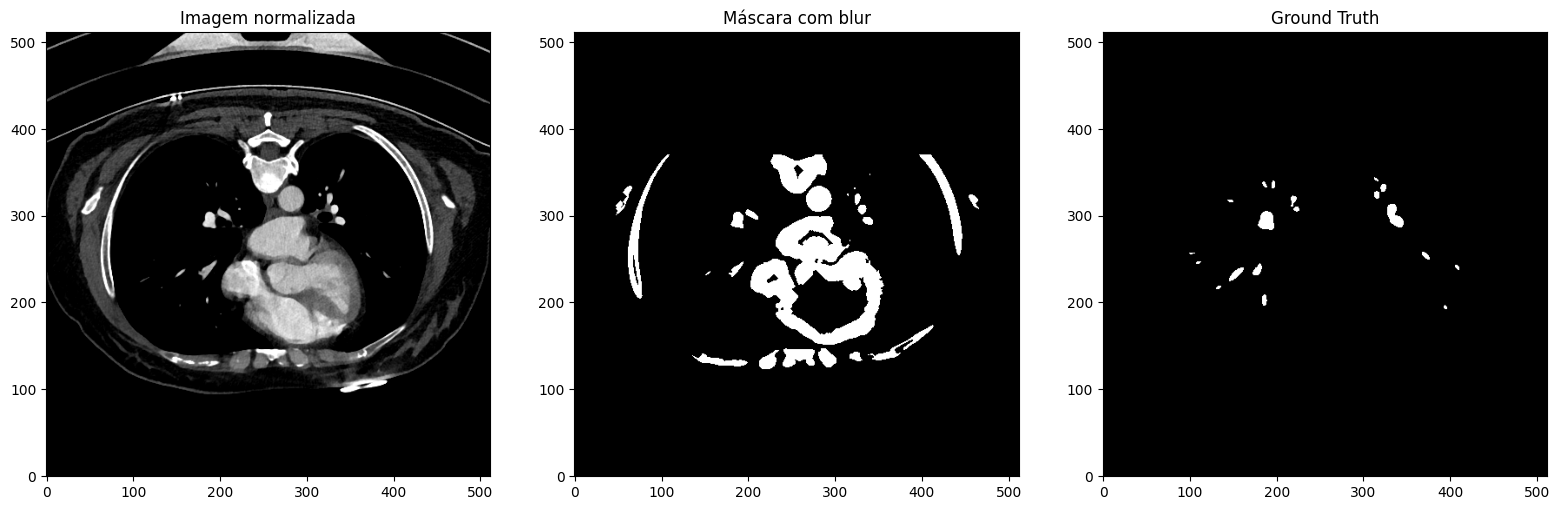

In [371]:
from scipy.ndimage import gaussian_filter

# Blur suave ANTES do threshold
# sigma pequeno — só para conectar pixels vizinhos, não borrar demais
img_blur = gaussian_filter(img_norm, sigma=1)

# Aplica ROI e corte superior
img_roi = img_blur.copy()
img_roi[~mascara_dilatada] = 0
img_roi[:, 370:, :] = 0

# Threshold
threshold = 0.4
mascara_vasos2 = img_roi > threshold

# Quantos componentes agora?
from scipy.ndimage import label
labeled, n = label(mascara_vasos2)
print(f"Componentes sem blur: 23298")
print(f"Componentes com blur: {n}")

# Visualiza
z = 129
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title('Imagem normalizada')
axes[1].imshow(mascara_vasos2[:, :, z].T, cmap='gray', origin='lower')
axes[1].set_title('Máscara com blur')
axes[2].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth')
plt.tight_layout()
plt.show()

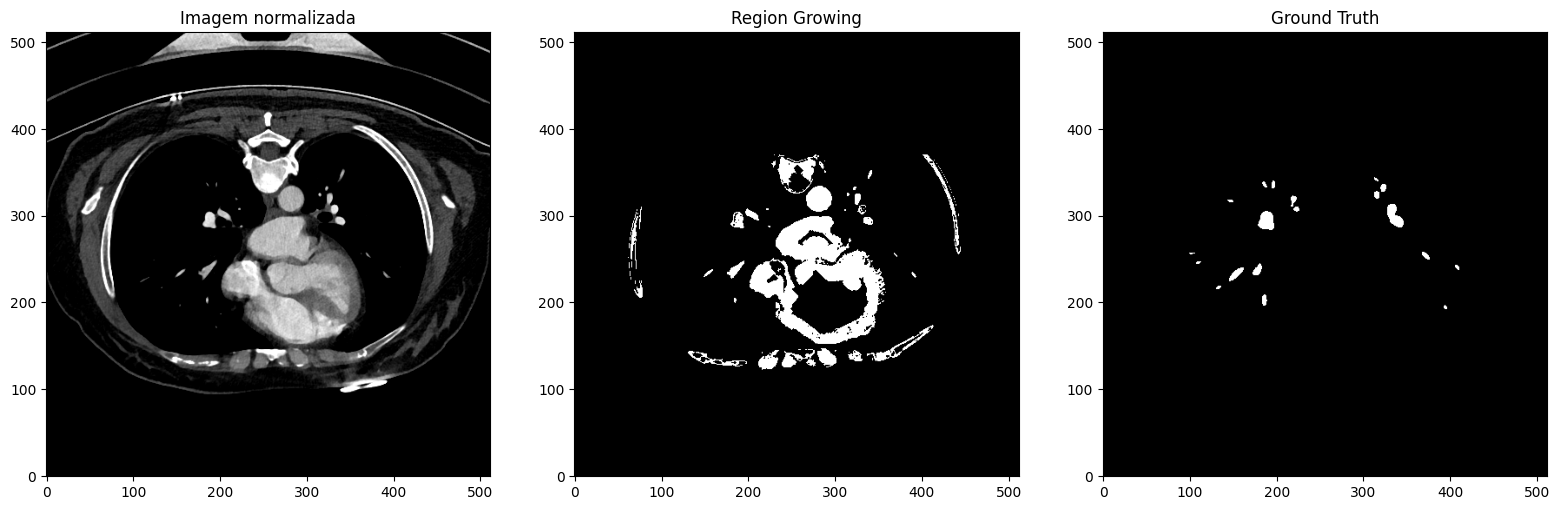

Voxels segmentados: 1714315


In [366]:
from collections import deque

def region_growing_3d(img_norm, mascara_vasos, seed, threshold_min, threshold_max):
    """
    Region Growing 3D.
    Só cresce em pixels que estão na mascara_vasos E dentro do threshold.
    """
    shape = img_norm.shape
    visitado = np.zeros(shape, dtype=bool)
    mascara_rg = np.zeros(shape, dtype=bool)

    fila = deque()
    fila.append(seed)
    visitado[seed] = True

    vizinhos = [(-1,0,0),(1,0,0),(0,-1,0),(0,1,0),(0,0,-1),(0,0,1)]

    while fila:
        x, y, z = fila.popleft()
        valor = img_norm[x, y, z]

        if threshold_min <= valor <= threshold_max and mascara_vasos[x, y, z]:
            mascara_rg[x, y, z] = True

            for dx, dy, dz in vizinhos:
                nx, ny, nz = x+dx, y+dy, z+dz
                if (0 <= nx < shape[0] and
                    0 <= ny < shape[1] and
                    0 <= nz < shape[2] and
                    not visitado[nx, ny, nz]):
                    visitado[nx, ny, nz] = True
                    fila.append((nx, ny, nz))

    return mascara_rg

# Seed no tronco pulmonar que identificamos antes
seed = (200, 270, 166)

mascara_rg = region_growing_3d(
    img_norm,
    mascara_vasos,
    seed,
    threshold_min=0.4,
    threshold_max=0.9
)

# Visualiza
z = 129
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title('Imagem normalizada')
axes[1].imshow(mascara_rg[:, :, z].T, cmap='gray', origin='lower')
axes[1].set_title('Region Growing')
axes[2].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth')
plt.tight_layout()
plt.show()

print(f"Voxels segmentados: {mascara_rg.sum()}")

Seed na mascara_vasos2: True


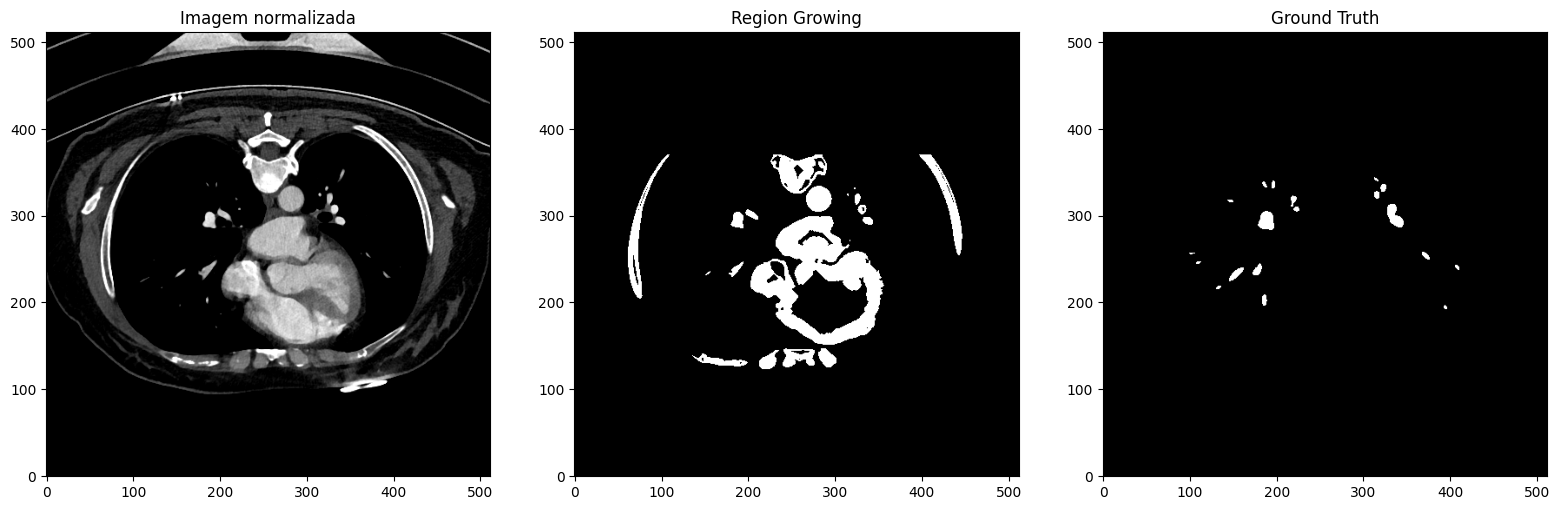

Voxels segmentados: 2068531
Voxels ground truth: 293043


In [372]:
from collections import deque

seed = (200, 270, 166)

# Confirma seed na nova máscara
print(f"Seed na mascara_vasos2: {mascara_vasos2[200, 270, 166]}")

mascara_rg = region_growing_3d(
    img_blur,        # usa a imagem com blur
    mascara_vasos2,  # máscara com blur
    seed,
    threshold_min=0.4,
    threshold_max=0.9
)

z = 129
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title('Imagem normalizada')
axes[1].imshow(mascara_rg[:, :, z].T, cmap='gray', origin='lower')
axes[1].set_title('Region Growing')
axes[2].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth')
plt.tight_layout()
plt.show()

print(f"Voxels segmentados: {mascara_rg.sum()}")
print(f"Voxels ground truth: {int(mask_volume.sum())}")

Total componentes: 515
Componente do seed: 14
Tamanho: 2269176 voxels


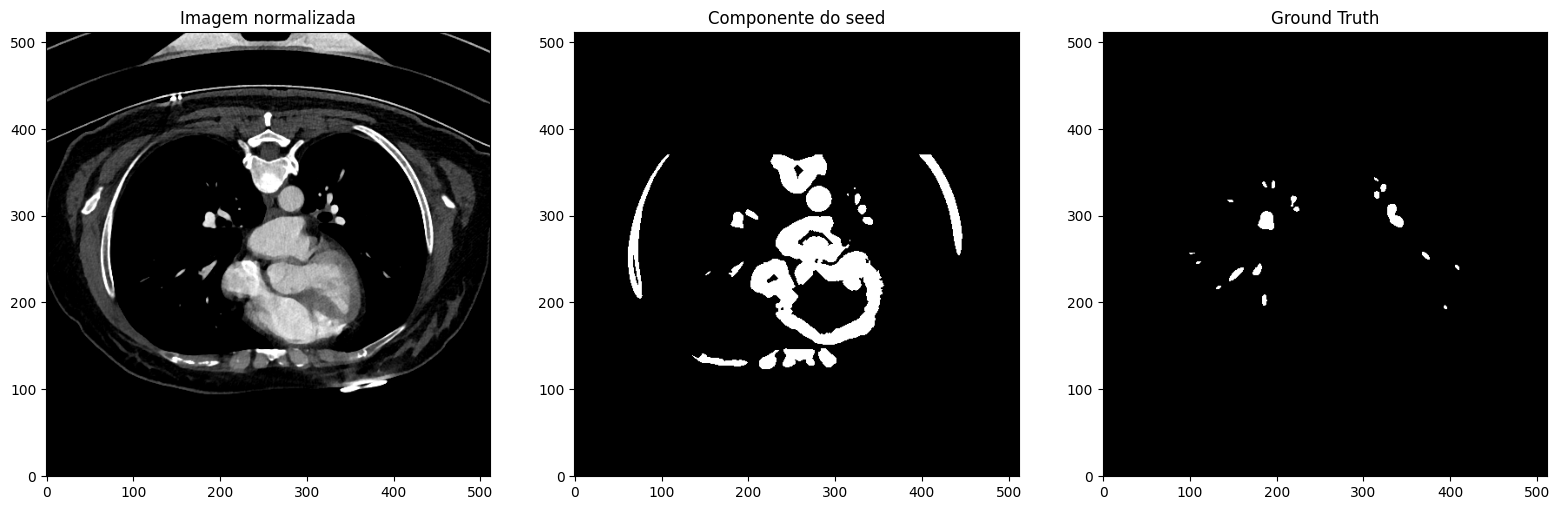

In [373]:
from scipy.ndimage import label

# Rotula os 515 componentes da mascara_vasos2
labeled, n = label(mascara_vasos2)
print(f"Total componentes: {n}")

# Qual componente contém o seed?
seed = (200, 270, 166)
comp_seed = labeled[seed]
print(f"Componente do seed: {comp_seed}")
print(f"Tamanho: {(labeled == comp_seed).sum()} voxels")

# Seleciona só esse componente
mascara_final = (labeled == comp_seed)

# Visualiza
z = 129
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title('Imagem normalizada')
axes[1].imshow(mascara_final[:, :, z].T, cmap='gray', origin='lower')
axes[1].set_title('Componente do seed')
axes[2].imshow(mask_volume[:, :, z].T, cmap='gray', origin='lower')
axes[2].set_title('Ground Truth')
plt.tight_layout()
plt.show()

# PARTE 3 - Testando thresholding simples

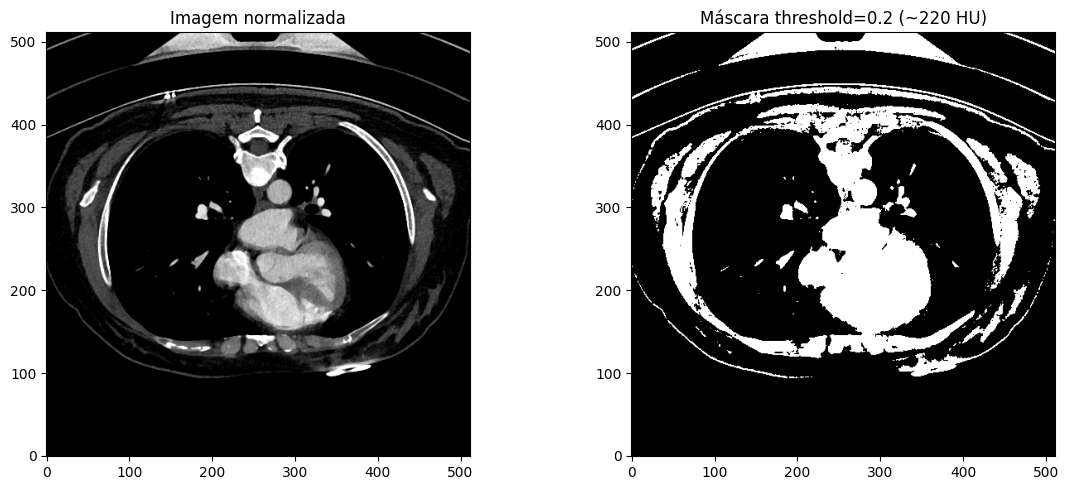

In [379]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Carregar
nii = ct_nifti
img = nii.get_fdata()

# Clip ajustado para vasos periféricos
img_clip = np.clip(img, -100, 400)
img_norm = (img_clip - (-100)) / (400 - (-100))  # 0–1

# Threshold em 0–1
threshold = 0.2  # equivale a 220 HU
mascara = img_norm > threshold

# Visualizar slice central
z = img.shape[2] // 2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_norm[:, :, z].T, cmap='gray', origin='lower')
axes[0].set_title('Imagem normalizada')
axes[1].imshow(mascara[:, :, z].T, cmap='gray', origin='lower')
axes[1].set_title(f'Máscara threshold={threshold} (~220 HU)')
plt.tight_layout()
plt.show()